# Consolidated Setup

In [1]:
!find /kaggle/input -maxdepth 6

/kaggle/input
/kaggle/input/models
/kaggle/input/models/minoola33
/kaggle/input/models/minoola33/gin-ames-mutagenicity
/kaggle/input/models/minoola33/gin-ames-mutagenicity/pytorch
/kaggle/input/models/minoola33/gin-ames-mutagenicity/pytorch/default
/kaggle/input/models/minoola33/gin-ames-mutagenicity/pytorch/default/1
/kaggle/input/models/minoola33/chemberta-v1-base-ames-mutagenicity
/kaggle/input/models/minoola33/chemberta-v1-base-ames-mutagenicity/pytorch
/kaggle/input/models/minoola33/chemberta-v1-base-ames-mutagenicity/pytorch/default
/kaggle/input/models/minoola33/chemberta-v1-base-ames-mutagenicity/pytorch/default/1
/kaggle/input/datasets
/kaggle/input/datasets/minoola33
/kaggle/input/datasets/minoola33/chemberta-gin-attributions
/kaggle/input/datasets/minoola33/chemberta-gin-attributions/gin_attributions.pkl
/kaggle/input/datasets/minoola33/chemberta-gin-attributions/chemberta_attributions.pkl
/kaggle/input/datasets/minoola33/mutagenicity-groundtruth-attributions
/kaggle/input/d

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
print("Torch version:", torch.__version__)
print("Torch's built-in CUDA version:", torch.version.cuda)

CUDA available: True
Device: Tesla T4
Torch version: 2.10.0+cu128
Torch's built-in CUDA version: 12.8


In [3]:
!pip install torch_geometric -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.1 MB/s eta 0:00:00


In [4]:
!pip install rdkit --no-deps

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 52.4 MB/s eta 0:00:00:00:0100:01


In [5]:
!pip install transformers PyTDC captum -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.2/154.2 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.3/151.3 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 8.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 9.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.1/151.1 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.2/151.2 kB 8.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━

In [6]:
# =========================================================
# SETUP
# =========================================================

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import re
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Data
from tdc.single_pred import Tox

device = "cuda" if torch.cuda.is_available() else "cpu"

CHEMBERTA_PATH = "/kaggle/input/models/minoola33/chemberta-v1-base-ames-mutagenicity/pytorch/default/1"
GIN_PATH = "/kaggle/input/models/minoola33/gin-ames-mutagenicity/pytorch/default/1/gin_ames_final.pt"
GIN_ATTRIBUTIONS_PICKLE = "/kaggle/input/datasets/minoola33/chemberta-gin-attributions/gin_attributions.pkl"
CHEMBERTA_ATTRIBUTIONS_PICKLE = "/kaggle/input/datasets/minoola33/chemberta-gin-attributions/chemberta_attributions.pkl"

# =========================================================
# Data (Phase 1 + 2A, self-contained)
# =========================================================
data = Tox(name='AMES')
df = data.get_data(format='df')
split = data.get_split(method="scaffold", seed=42, frac=[0.7, 0.1, 0.2])
train_df, valid_df, test_df = split['train'], split['valid'], split['test']

remover = SaltRemover()
def standardize_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = remover.StripMol(mol, dontRemoveEverything=True)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

df['Drug_standardized'] = df['Drug'].apply(standardize_smiles)
df_clean = df[df['Drug_standardized'].notna()].copy()
train_ids, valid_ids, test_ids = set(train_df['Drug_ID']), set(valid_df['Drug_ID']), set(test_df['Drug_ID'])
df_clean['split'] = df_clean['Drug_ID'].apply(
    lambda i: 'train' if i in train_ids else ('valid' if i in valid_ids else ('test' if i in test_ids else 'unknown')))
assert (df_clean['split'] == 'unknown').sum() == 0

# =========================================================
# Models (Phase 3/4, reload from Kaggle Models)
# =========================================================
tokenizer = AutoTokenizer.from_pretrained(CHEMBERTA_PATH)
chemberta_model = AutoModelForSequenceClassification.from_pretrained(CHEMBERTA_PATH).to(device)
chemberta_model.eval()

class GIN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(num_layers):
            mlp = nn.Sequential(nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),
                                 nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_add_pool(x, batch)
        return self.classifier(x).squeeze(-1)

gin_model = GIN(in_dim=6).to(device)
gin_model.load_state_dict(torch.load(GIN_PATH, map_location=device))
gin_model.eval()

# =========================================================
# Precomputed attributions (Phase 4)
# =========================================================
with open(GIN_ATTRIBUTIONS_PICKLE, "rb") as f:
    gin_attributions = pickle.load(f)
with open(CHEMBERTA_ATTRIBUTIONS_PICKLE, "rb") as f:
    chemberta_results = pickle.load(f)

# =========================================================
# Atom char-span extraction (Phase 4, verified)
# =========================================================
SMILES_TOKEN_REGEX = re.compile(
    r"(\[[^\]]+\]|Br|Cl|[BCNOSPFI]|[bcnosp]|\(|\)|\.|=|#|-|\+|\\|/|:|~|@|\?|>|\*|\$|%[0-9]{2}|[0-9])"
)
def get_atom_char_spans(smiles):
    atom_spans = []
    for match in SMILES_TOKEN_REGEX.finditer(smiles):
        token = match.group(0)
        start, end = match.span()
        is_atom = (token.startswith('[') or token in ('Br', 'Cl') or
                   token in ('B', 'C', 'N', 'O', 'S', 'P', 'F', 'I') or
                   token in ('b', 'c', 'n', 'o', 's', 'p'))
        if is_atom:
            atom_spans.append((start, end))
    return atom_spans

# =========================================================
# Token-to-atom alignment (Phase 4, magnitude-fixed version)
# =========================================================
def align_tokens_to_atoms(tokens, token_scores, token_offsets, atom_spans):
    special_token_mass_signed = 0.0
    special_token_mass_abs = 0.0
    max_char = max(end for (_, end) in atom_spans)
    max_char = max(max_char, max((end for (_, end) in token_offsets), default=0))
    char_mass_signed = np.zeros(max_char)
    char_mass_abs = np.zeros(max_char)

    for tok, score, (start, end) in zip(tokens, token_scores, token_offsets):
        if end <= start:
            special_token_mass_signed += score
            special_token_mass_abs += abs(score)
            continue
        length = end - start
        char_mass_signed[start:end] += score / length
        char_mass_abs[start:end] += abs(score) / length

    atom_scores = np.zeros(len(atom_spans))
    atom_scores_abs = np.zeros(len(atom_spans))
    covered = np.zeros(max_char, dtype=bool)
    for i, (start, end) in enumerate(atom_spans):
        atom_scores[i] = char_mass_signed[start:end].sum()
        atom_scores_abs[i] = char_mass_abs[start:end].sum()
        covered[start:end] = True

    syntax_mass_abs = char_mass_abs[~covered].sum()
    unassigned_mass_abs = special_token_mass_abs + syntax_mass_abs
    total_mass_abs = char_mass_abs.sum() + special_token_mass_abs
    unassigned_fraction = unassigned_mass_abs / total_mass_abs if total_mass_abs > 1e-8 else float('nan')

    return {"atom_scores": atom_scores, "unassigned_mass_abs": unassigned_mass_abs,
            "total_mass_abs": total_mass_abs, "unassigned_fraction": unassigned_fraction}

# =========================================================
# ChemBERTa token attribution extraction (Phase 4)
# =========================================================
from captum.attr import LayerIntegratedGradients

def chemberta_forward(input_ids, attention_mask):
    return chemberta_model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(chemberta_forward, chemberta_model.roberta.embeddings)

def get_chemberta_token_attributions(smiles, target_class=1, n_steps=50, max_length=128):
    encoded = tokenizer(smiles, return_tensors="pt", return_offsets_mapping=True,
                         truncation=True, max_length=max_length)
    offsets = encoded.pop("offset_mapping")[0].tolist()
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    real_len = int(attention_mask.sum().item())

    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline_ids[0, 0] = input_ids[0, 0]
    baseline_ids[0, real_len - 1] = input_ids[0, real_len - 1]

    attributions, delta = lig.attribute(
        inputs=input_ids, baselines=baseline_ids, additional_forward_args=(attention_mask,),
        target=target_class, n_steps=n_steps, return_convergence_delta=True)

    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    return tokens[:real_len], token_scores[:real_len], offsets[:real_len], delta.item()

def full_chemberta_atom_pipeline(smiles, n_steps=50):
    tokens, scores, offsets, delta = get_chemberta_token_attributions(smiles, n_steps=n_steps)
    mol = Chem.MolFromSmiles(smiles)
    spans = get_atom_char_spans(smiles)
    if mol.GetNumAtoms() != len(spans):
        return None
    result = align_tokens_to_atoms(tokens, scores, offsets, spans)
    result["convergence_delta"] = delta
    result["num_atoms"] = mol.GetNumAtoms()
    result["num_rings"] = mol.GetRingInfo().NumRings()
    return result

# =========================================================
# Masking primitives (Phase 5, edge-case verified)
# =========================================================
def mask_atoms_gin(x, atom_indices_to_mask):
    x_masked = x.clone()
    if len(atom_indices_to_mask) > 0:
        x_masked[list(atom_indices_to_mask), :] = 0.0
    return x_masked

def predict_gin_masked(data, atom_indices_to_mask):
    data = data.to(device)
    x_masked = mask_atoms_gin(data.x, atom_indices_to_mask)
    batch = torch.zeros(x_masked.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        return gin_model(x_masked, data.edge_index, batch).item()

def get_tokens_to_mask(atom_indices_to_mask, atom_spans, token_offsets):
    target_ranges = [atom_spans[i] for i in atom_indices_to_mask]
    def overlaps(a, b):
        return a[0] < b[1] and b[0] < a[1]
    token_positions = set()
    for tok_idx, (t_start, t_end) in enumerate(token_offsets):
        if t_end <= t_start:
            continue
        if any(overlaps((t_start, t_end), target) for target in target_ranges):
            token_positions.add(tok_idx)
    collateral_atoms = set()
    for tok_idx in token_positions:
        t_start, t_end = token_offsets[tok_idx]
        for atom_idx, (a_start, a_end) in enumerate(atom_spans):
            if overlaps((t_start, t_end), (a_start, a_end)):
                collateral_atoms.add(atom_idx)
    collateral_atoms -= set(atom_indices_to_mask)
    return sorted(token_positions), sorted(collateral_atoms)

def predict_chemberta_masked(smiles, atom_indices_to_mask, max_length=128):
    encoded = tokenizer(smiles, return_tensors="pt", return_offsets_mapping=True,
                         truncation=True, max_length=max_length)
    offsets = encoded.pop("offset_mapping")[0].tolist()
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    real_len = int(attention_mask.sum().item())
    real_offsets = offsets[:real_len]

    spans = get_atom_char_spans(smiles)
    tok_positions, collateral = get_tokens_to_mask(atom_indices_to_mask, spans, real_offsets)

    input_ids_masked = input_ids.clone()
    for pos in tok_positions:
        input_ids_masked[0, pos] = tokenizer.pad_token_id

    with torch.no_grad():
        logits = chemberta_model(input_ids=input_ids_masked, attention_mask=attention_mask).logits
    return logits[0, 1].item(), collateral

def get_true_baseline_prediction(smiles, max_length=128):
    encoded = tokenizer(smiles, return_tensors="pt", truncation=True, max_length=max_length)
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    real_len = int(attention_mask.sum().item())
    baseline_ids = torch.full_like(input_ids, tokenizer.pad_token_id)
    baseline_ids[0, 0] = input_ids[0, 0]
    baseline_ids[0, real_len - 1] = input_ids[0, real_len - 1]
    with torch.no_grad():
        logits = chemberta_model(input_ids=baseline_ids, attention_mask=attention_mask).logits
    return logits[0, 1].item()

print("Setup complete. All Phase 4/5 verified functions loaded.")
print(f"df_clean: {len(df_clean)} molecules, test split: {(df_clean['split']=='test').sum()}")
print(f"gin_attributions: {len(gin_attributions)} molecules")
print(f"chemberta_results: {len(chemberta_results)} molecules")

Downloading...
100%|██████████| 344k/344k [00:00<00:00, 52.4MiB/s]
Loading...
Done!
100%|██████████| 7278/7278 [00:01<00:00, 4464.93it/s]


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Setup complete. All Phase 4/5 verified functions loaded.
df_clean: 7278 molecules, test split: 1457
gin_attributions: 1457 molecules
chemberta_results: 1457 molecules


In [8]:
from rdkit import Chem
from torch_geometric.data import Data

def mol_to_data(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    atom_feats = []
    for atom in mol.GetAtoms():
        atom_feats.append([
            atom.GetAtomicNum(), atom.GetDegree(), atom.GetFormalCharge(),
            int(atom.GetHybridization()), int(atom.GetIsAromatic()), atom.GetTotalNumHs(),
        ])
    x = torch.tensor(atom_feats, dtype=torch.float)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
    edge_index = (torch.tensor(edge_index, dtype=torch.long).t().contiguous()
                  if edge_index else torch.zeros((2, 0), dtype=torch.long))
    return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.float))

test_df_local = df_clean[df_clean['split'] == 'test'].reset_index(drop=True)

# Build Drug_ID-keyed lookups for GIN data objects and ChemBERTa SMILES strings,
# ensuring alignment across models and attribution dictionaries even if an entry is missing.
gin_data_by_id = {}
smiles_by_id = {}
for _, row in test_df_local.iterrows():
    d = mol_to_data(row['Drug_standardized'], row['Y'])
    if d is not None:
        gin_data_by_id[row['Drug_ID']] = d
    smiles_by_id[row['Drug_ID']] = row['Drug_standardized']

print(f"gin_data_by_id: {len(gin_data_by_id)} molecules")
print(f"smiles_by_id: {len(smiles_by_id)} molecules")

# Set the sample molecule using Drug_ID rather than position-based indexing
sample_drug_id = test_df_local.iloc[0]['Drug_ID']
sample_data = gin_data_by_id[sample_drug_id]
sample_smiles = smiles_by_id[sample_drug_id]
print(f"\nsample_drug_id = {sample_drug_id}")
print(f"sample_smiles = {sample_smiles}")

gin_data_by_id: 1457 molecules
smiles_by_id: 1457 molecules

sample_drug_id = Drug 1
sample_smiles = O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2


#### Comprehensiveness and Sufficiency (Fidelity+ / Fidelity-)

In [9]:
def top_k_indices_by_abs(atom_scores, fraction=0.2):
    """Returns top-k atom indices ranked by absolute attribution magnitude."""
    k = max(1, int(np.ceil(len(atom_scores) * fraction)))
    return list(np.argsort(-np.abs(atom_scores))[:k])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# --- GIN: comprehensiveness & sufficiency for ONE molecule ---
def gin_comprehensiveness_sufficiency(data, atom_scores, fraction=0.2):
    n_atoms = data.x.size(0)
    top_k = top_k_indices_by_abs(atom_scores, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]

    p_full = sigmoid(predict_gin_masked(data, []))
    p_removed = sigmoid(predict_gin_masked(data, top_k))         # Top-k removed
    p_kept_only = sigmoid(predict_gin_masked(data, complement))    # Only top-k kept

    comprehensiveness = p_full - p_removed
    sufficiency = p_full - p_kept_only
    return comprehensiveness, sufficiency, p_full, p_removed, p_kept_only

# --- ChemBERTa: comprehensiveness & sufficiency for ONE molecule ---
def chemberta_comprehensiveness_sufficiency(smiles, atom_scores, fraction=0.2):
    n_atoms = len(atom_scores)
    top_k = top_k_indices_by_abs(atom_scores, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]

    p_full = sigmoid(predict_chemberta_masked(smiles, [])[0])
    p_removed, collateral_removed = predict_chemberta_masked(smiles, top_k)
    p_removed = sigmoid(p_removed)
    p_kept_only, collateral_kept = predict_chemberta_masked(smiles, complement)
    p_kept_only = sigmoid(p_kept_only)

    comprehensiveness = p_full - p_removed
    sufficiency = p_full - p_kept_only
    return (comprehensiveness, sufficiency, p_full, p_removed, p_kept_only,
            collateral_removed, collateral_kept)

# --- Hand-check on the sample molecule for both models ---
sample_drug_id = test_df_ordered_cb.iloc[0]['Drug_ID'] if 'test_df_ordered_cb' in dir() else \
                 df_clean[df_clean['split'] == 'test'].iloc[0]['Drug_ID']

gin_scores = gin_attributions[sample_drug_id]
comp_g, suff_g, pf_g, pr_g, pk_g = gin_comprehensiveness_sufficiency(sample_data, gin_scores)
print("=== GIN (sample molecule) ===")
print(f"P(full)={pf_g:.4f}  P(top-20% removed)={pr_g:.4f}  P(only top-20% kept)={pk_g:.4f}")
print(f"Comprehensiveness (Fidelity+): {comp_g:.4f}   (higher = more faithful)")
print(f"Sufficiency (Fidelity-):        {suff_g:.4f}   (lower = more faithful)")

cb_scores = chemberta_results[sample_drug_id]["atom_scores"]
result_cb = chemberta_comprehensiveness_sufficiency(sample_smiles, cb_scores)
comp_c, suff_c, pf_c, pr_c, pk_c, coll_removed, coll_kept = result_cb
print("\n=== ChemBERTa (sample molecule) ===")
print(f"P(full)={pf_c:.4f}  P(top-20% removed)={pr_c:.4f}  P(only top-20% kept)={pk_c:.4f}")
print(f"Comprehensiveness (Fidelity+): {comp_c:.4f}   (higher = more faithful)")
print(f"Sufficiency (Fidelity-):        {suff_c:.4f}   (lower = more faithful)")
print(f"Collateral atoms (removed case): {coll_removed}")
print(f"Collateral atoms (kept-only case): {coll_kept}")

=== GIN (sample molecule) ===
P(full)=0.9157  P(top-20% removed)=0.0000  P(only top-20% kept)=0.0000
Comprehensiveness (Fidelity+): 0.9157   (higher = more faithful)
Sufficiency (Fidelity-):        0.9157   (lower = more faithful)

=== ChemBERTa (sample molecule) ===
P(full)=0.7630  P(top-20% removed)=0.8905  P(only top-20% kept)=0.8271
Comprehensiveness (Fidelity+): -0.1275   (higher = more faithful)
Sufficiency (Fidelity-):        -0.0641   (lower = more faithful)
Collateral atoms (removed case): [2, 13]
Collateral atoms (kept-only case): [1, 10, 11, 12]


#### Some Diagnostics for the Anomaly

In [10]:
# Diagnostic 1: check if GIN is fragile to any random 20% removal regardless of importance.
np.random.seed(0)
n_atoms_gin = sample_data.x.size(0)
k = max(1, int(np.ceil(n_atoms_gin * 0.2)))

random_subset = list(np.random.choice(n_atoms_gin, size=k, replace=False))
top20_subset = top_k_indices_by_abs(gin_attributions[sample_drug_id], 0.2)

p_full_gin = sigmoid(predict_gin_masked(sample_data, []))
p_random_removed = sigmoid(predict_gin_masked(sample_data, random_subset))
p_top20_removed = sigmoid(predict_gin_masked(sample_data, top20_subset))

print("=== GIN: is comprehensiveness discriminating, or just generic fragility? ===")
print(f"P(full) = {p_full_gin:.4f}")
print(f"P(random 20% removed)  = {p_random_removed:.4f}")
print(f"P(top-20% removed)     = {p_top20_removed:.4f}")
print("If both are close to zero, GIN saturates from any substantial removal, meaning comprehensiveness needs a random baseline correction.")

# Diagnostic 2: ranking atoms based on the prediction direction rather than absolute values.
def top_k_indices_signed(atom_scores, p_full, fraction=0.2):
    """Selects top-k atoms supporting the prediction direction (positive for mutagenic, negative for non-mutagenic)."""
    k = max(1, int(np.ceil(len(atom_scores) * fraction)))
    if p_full > 0.5:
        order = np.argsort(-atom_scores)  # Most positive first
    else:
        order = np.argsort(atom_scores)   # Most negative first
    return list(order[:k])

def comprehensiveness_sufficiency_signed_gin(data, atom_scores, fraction=0.2):
    n_atoms = data.x.size(0)
    p_full = sigmoid(predict_gin_masked(data, []))
    top_k = top_k_indices_signed(atom_scores, p_full, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]
    p_removed = sigmoid(predict_gin_masked(data, top_k))
    p_kept_only = sigmoid(predict_gin_masked(data, complement))
    return p_full - p_removed, p_full - p_kept_only, p_full, p_removed, p_kept_only

def comprehensiveness_sufficiency_signed_chemberta(smiles, atom_scores, fraction=0.2):
    n_atoms = len(atom_scores)
    p_full = sigmoid(predict_chemberta_masked(smiles, [])[0])
    top_k = top_k_indices_signed(atom_scores, p_full, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]
    p_removed = sigmoid(predict_chemberta_masked(smiles, top_k)[0])
    p_kept_only = sigmoid(predict_chemberta_masked(smiles, complement)[0])
    return p_full - p_removed, p_full - p_kept_only, p_full, p_removed, p_kept_only

comp_g2, suff_g2, pf_g2, pr_g2, pk_g2 = comprehensiveness_sufficiency_signed_gin(
    sample_data, gin_attributions[sample_drug_id])
print("\n=== GIN, prediction-direction-aware ranking ===")
print(f"P(full)={pf_g2:.4f}  P(removed)={pr_g2:.4f}  P(kept-only)={pk_g2:.4f}")
print(f"Comprehensiveness: {comp_g2:.4f}   Sufficiency: {suff_g2:.4f}")

comp_c2, suff_c2, pf_c2, pr_c2, pk_c2 = comprehensiveness_sufficiency_signed_chemberta(
    sample_smiles, chemberta_results[sample_drug_id]["atom_scores"])
print("\n=== ChemBERTa, prediction-direction-aware ranking ===")
print(f"P(full)={pf_c2:.4f}  P(removed)={pr_c2:.4f}  P(kept-only)={pk_c2:.4f}")
print(f"Comprehensiveness: {comp_c2:.4f}   Sufficiency: {suff_c2:.4f}")
print("\nExpect comprehensiveness to be positive for both models.")

=== GIN: is comprehensiveness discriminating, or just generic fragility? ===
P(full) = 0.9157
P(random 20% removed)  = 0.0001
P(top-20% removed)     = 0.0000
If both are close to zero, GIN saturates from any substantial removal, meaning comprehensiveness needs a random baseline correction.

=== GIN, prediction-direction-aware ranking ===
P(full)=0.9157  P(removed)=0.0000  P(kept-only)=0.0000
Comprehensiveness: 0.9157   Sufficiency: 0.9157

=== ChemBERTa, prediction-direction-aware ranking ===
P(full)=0.7630  P(removed)=0.8371  P(kept-only)=0.7977
Comprehensiveness: -0.0741   Sufficiency: -0.0348

Expect comprehensiveness to be positive for both models.


#### Random Baseline and Collateral Check

In [11]:
def random_baseline_comprehensiveness_gin(data, k, n_random=10, seed_base=0):
    p_full = sigmoid(predict_gin_masked(data, []))
    n_atoms = data.x.size(0)
    comps = []
    for s in range(n_random):
        rng = np.random.RandomState(seed_base + s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        p_r = sigmoid(predict_gin_masked(data, subset))
        comps.append(p_full - p_r)
    return np.mean(comps), np.std(comps)

def random_baseline_comprehensiveness_chemberta(smiles, k, n_random=10, seed_base=0):
    p_full = sigmoid(predict_chemberta_masked(smiles, [])[0])
    n_atoms = len(get_atom_char_spans(smiles))
    comps = []
    for s in range(n_random):
        rng = np.random.RandomState(seed_base + s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        p_r = sigmoid(predict_chemberta_masked(smiles, subset)[0])
        comps.append(p_full - p_r)
    return np.mean(comps), np.std(comps)

# Compute corrected comprehensiveness for GIN against the random baseline
p_full_g = sigmoid(predict_gin_masked(sample_data, []))
top_k_g = top_k_indices_signed(gin_attributions[sample_drug_id], p_full_g, 0.2)
comp_top_g = p_full_g - sigmoid(predict_gin_masked(sample_data, top_k_g))
rand_mean_g, rand_std_g = random_baseline_comprehensiveness_gin(sample_data, len(top_k_g))

print("=== GIN: comprehensiveness vs random baseline ===")
print(f"Top-k comprehensiveness:        {comp_top_g:.4f}")
print(f"Random-k comprehensiveness:     {rand_mean_g:.4f}  (std {rand_std_g:.4f}, n=10)")
print(f"CORRECTED (discriminative) score: {comp_top_g - rand_mean_g:.4f}")
print("Values near zero indicate that top-k removal is no more damaging than random removal.")

# Compute corrected comprehensiveness for ChemBERTa against the random baseline
p_full_c = sigmoid(predict_chemberta_masked(sample_smiles, [])[0])
cb_scores = chemberta_results[sample_drug_id]["atom_scores"]
top_k_c = top_k_indices_signed(cb_scores, p_full_c, 0.2)
p_removed_c, collateral_c = predict_chemberta_masked(sample_smiles, top_k_c)
comp_top_c = p_full_c - sigmoid(p_removed_c)
rand_mean_c, rand_std_c = random_baseline_comprehensiveness_chemberta(sample_smiles, len(top_k_c))

print("\n=== ChemBERTa: comprehensiveness vs random baseline ===")
print(f"Top-k comprehensiveness:        {comp_top_c:.4f}")
print(f"Random-k comprehensiveness:     {rand_mean_c:.4f}  (std {rand_std_c:.4f}, n=10)")
print(f"CORRECTED (discriminative) score: {comp_top_c - rand_mean_c:.4f}")

# Execute collateral sign diagnostic for ChemBERTa
print("\n=== ChemBERTa: is the negative result a masking artifact? ===")
print(f"Intended top-k atoms: {top_k_c}")
print(f"Their attribution scores: {[round(cb_scores[i], 4) for i in top_k_c]}")
print(f"Collateral atoms pulled in via shared tokens: {collateral_c}")
print(f"Their attribution scores: {[round(cb_scores[i], 4) for i in collateral_c]}")
if collateral_c:
    collateral_sum = sum(cb_scores[i] for i in collateral_c)
    print(f"Sum of collateral attribution: {collateral_sum:.4f}")
    print("Negative collateral sums indicate a masking artifact rather than a deep faithfulness finding.")
    print("Near-zero or positive collateral sums point toward a genuine local-versus-global attribution gap.")
else:
    print("No collateral atoms were detected, confirming negative comprehensiveness is not a masking artifact.")

=== GIN: comprehensiveness vs random baseline ===
Top-k comprehensiveness:        0.9157
Random-k comprehensiveness:     0.9156  (std 0.0001, n=10)
CORRECTED (discriminative) score: 0.0001
Values near zero indicate that top-k removal is no more damaging than random removal.

=== ChemBERTa: comprehensiveness vs random baseline ===
Top-k comprehensiveness:        -0.0741
Random-k comprehensiveness:     -0.1162  (std 0.0357, n=10)
CORRECTED (discriminative) score: 0.0421

=== ChemBERTa: is the negative result a masking artifact? ===
Intended top-k atoms: [np.int64(12), np.int64(13), np.int64(10), np.int64(11), np.int64(17)]
Their attribution scores: [np.float64(0.1306), np.float64(0.1306), np.float64(0.1306), np.float64(0.1306), np.float64(0.0945)]
Collateral atoms pulled in via shared tokens: []
Their attribution scores: []
No collateral atoms were detected, confirming negative comprehensiveness is not a masking artifact.


#### Multi-molecule Check

In [12]:
import random
random.seed(42)

sample_ids = random.sample(list(gin_data_by_id.keys()), 15)

print(f"{'Drug_ID':10s} {'GIN raw':>10s} {'GIN corr':>10s} {'CB raw':>10s} {'CB corr':>10s}")
gin_corrs, cb_corrs = [], []

for drug_id in sample_ids:
    if drug_id not in chemberta_results:
        continue
    data = gin_data_by_id[drug_id]
    smiles = smiles_by_id[drug_id]
    g_scores = gin_attributions[drug_id]
    c_scores = chemberta_results[drug_id]["atom_scores"]

    p_full_g = sigmoid(predict_gin_masked(data, []))
    top_k_g = top_k_indices_signed(g_scores, p_full_g, 0.2)
    comp_top_g = p_full_g - sigmoid(predict_gin_masked(data, top_k_g))
    rand_mean_g, _ = random_baseline_comprehensiveness_gin(data, len(top_k_g), n_random=5)
    corr_g = comp_top_g - rand_mean_g

    p_full_c = sigmoid(predict_chemberta_masked(smiles, [])[0])
    top_k_c = top_k_indices_signed(c_scores, p_full_c, 0.2)
    comp_top_c = p_full_c - sigmoid(predict_chemberta_masked(smiles, top_k_c)[0])
    rand_mean_c, _ = random_baseline_comprehensiveness_chemberta(smiles, len(top_k_c), n_random=5)
    corr_c = comp_top_c - rand_mean_c

    gin_corrs.append(corr_g)
    cb_corrs.append(corr_c)
    print(f"{drug_id:10s} {comp_top_g:10.4f} {corr_g:10.4f} {comp_top_c:10.4f} {corr_c:10.4f}")

import numpy as np
print(f"\nGIN corrected score  -- mean: {np.mean(gin_corrs):.4f}, std: {np.std(gin_corrs):.4f}")
print(f"ChemBERTa corrected score -- mean: {np.mean(cb_corrs):.4f}, std: {np.std(cb_corrs):.4f}")

Drug_ID       GIN raw   GIN corr     CB raw    CB corr
Drug 6818      0.8609     0.0003     0.1517     0.3829
Drug 1085      0.4491    -0.0247     0.4164     0.2404
Drug 256       0.1689    -0.0067    -0.2951    -0.0819
Drug 2873      0.1933    -0.0066    -0.3764    -0.0089
Drug 2545      0.0458    -0.2338     0.0576     0.0159
Drug 2315      0.6649     0.0000     0.1375     0.3014
Drug 1360      0.7249     0.0000     0.2135     0.3570
Drug 951       0.7403    -0.0000     0.4480     0.3689
Drug 7102      0.2061    -0.0140    -0.0374     0.0650
Drug 5927      0.3136    -0.0608     0.4381     0.2537
Drug 810       0.2053    -0.0029     0.4256     0.3913
Drug 6357      0.2887    -0.0014     0.0587     0.1682
Drug 4534     -0.0233    -0.0356    -0.0333     0.2316
Drug 296       0.1000    -0.0132    -0.0852     0.1484
Drug 286       0.6966     0.0011    -0.1326     0.0268

GIN corrected score  -- mean: -0.0265, std: 0.0578
ChemBERTa corrected score -- mean: 0.1907, std: 0.1520


# Phase 5B - Full Test-set Run: Comprehensiveness and Sufficiency
#### Random Baseline Corrected, Both Models, Full-scale, Other Significant Tests

In [13]:
import time
from scipy import stats

N_RANDOM = 10
FRACTION = 0.2

def compute_corrected_metrics_gin(data, atom_scores, n_random=N_RANDOM, fraction=FRACTION):
    """Computes corrected comprehensiveness and sufficiency metrics for GIN."""
    n_atoms = data.x.size(0)
    p_full = sigmoid(predict_gin_masked(data, []))
    top_k = top_k_indices_signed(atom_scores, p_full, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]

    p_removed = sigmoid(predict_gin_masked(data, top_k))
    p_kept_only = sigmoid(predict_gin_masked(data, complement))
    comp_top = p_full - p_removed
    suff_top = p_full - p_kept_only

    k = len(top_k)
    rand_comps, rand_suffs = [], []
    for s in range(n_random):
        rng = np.random.RandomState(s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        rand_complement = [i for i in range(n_atoms) if i not in subset]
        rand_comps.append(p_full - sigmoid(predict_gin_masked(data, subset)))
        rand_suffs.append(p_full - sigmoid(predict_gin_masked(data, rand_complement)))

    rand_comp_mean = float(np.mean(rand_comps))
    rand_suff_mean = float(np.mean(rand_suffs))

    return {
        "p_full": p_full, "comp_raw": comp_top, "suff_raw": suff_top,
        "comp_random": rand_comp_mean, "suff_random": rand_suff_mean,
        "comp_corrected": comp_top - rand_comp_mean,
        "suff_corrected": rand_suff_mean - suff_top,
    }

def compute_corrected_metrics_chemberta(smiles, atom_scores, n_random=N_RANDOM, fraction=FRACTION):
    """Computes corrected comprehensiveness and sufficiency metrics for ChemBERTa."""
    n_atoms = len(atom_scores)
    p_full = sigmoid(predict_chemberta_masked(smiles, [])[0])
    top_k = top_k_indices_signed(atom_scores, p_full, fraction)
    complement = [i for i in range(n_atoms) if i not in top_k]

    p_removed, coll_removed = predict_chemberta_masked(smiles, top_k)
    p_kept_only, coll_kept = predict_chemberta_masked(smiles, complement)
    comp_top = p_full - sigmoid(p_removed)
    suff_top = p_full - sigmoid(p_kept_only)

    k = len(top_k)
    rand_comps, rand_suffs = [], []
    for s in range(n_random):
        rng = np.random.RandomState(s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        rand_complement = [i for i in range(n_atoms) if i not in subset]
        rand_comps.append(p_full - sigmoid(predict_chemberta_masked(smiles, subset)[0]))
        rand_suffs.append(p_full - sigmoid(predict_chemberta_masked(smiles, rand_complement)[0]))

    rand_comp_mean = float(np.mean(rand_comps))
    rand_suff_mean = float(np.mean(rand_suffs))

    return {
        "p_full": p_full, "comp_raw": comp_top, "suff_raw": suff_top,
        "comp_random": rand_comp_mean, "suff_random": rand_suff_mean,
        "comp_corrected": comp_top - rand_comp_mean,
        "suff_corrected": rand_suff_mean - suff_top,
        "collateral_removed": coll_removed, "collateral_kept": coll_kept,
    }

# Execute full test-set evaluation loop across both models
test_drug_ids = list(smiles_by_id.keys())
gin_metrics, chemberta_metrics = {}, {}
failed_gin, failed_cb = 0, 0
start = time.time()

for i, drug_id in enumerate(test_drug_ids):
    if drug_id in gin_data_by_id and drug_id in gin_attributions:
        try:
            gin_metrics[drug_id] = compute_corrected_metrics_gin(
                gin_data_by_id[drug_id], gin_attributions[drug_id])
        except Exception:
            failed_gin += 1

    if drug_id in chemberta_results:
        try:
            chemberta_metrics[drug_id] = compute_corrected_metrics_chemberta(
                smiles_by_id[drug_id], chemberta_results[drug_id]["atom_scores"])
        except Exception:
            failed_cb += 1

    if (i + 1) % 100 == 0 or (i + 1) == len(test_drug_ids):
        elapsed = time.time() - start
        print(f"  {i + 1}/{len(test_drug_ids)}  "
              f"(GIN ok: {len(gin_metrics)}, fail: {failed_gin}; "
              f"CB ok: {len(chemberta_metrics)}, fail: {failed_cb})  "
              f"elapsed: {elapsed:.0f}s")

print(f"\nDone. GIN: {len(gin_metrics)}/{len(test_drug_ids)}. "
      f"ChemBERTa: {len(chemberta_metrics)}/{len(test_drug_ids)}.")

with open("/kaggle/working/gin_faithfulness_metrics.pkl", "wb") as f:
    pickle.dump(gin_metrics, f)
with open("/kaggle/working/chemberta_faithfulness_metrics.pkl", "wb") as f:
    pickle.dump(chemberta_metrics, f)
print("Saved both metric pickles to /kaggle/working/")

# Perform paired statistical comparisons across models for shared molecules
common_ids = sorted(set(gin_metrics.keys()) & set(chemberta_metrics.keys()))
print(f"\nMolecules with BOTH models' metrics: {len(common_ids)}")

gin_comp = np.array([gin_metrics[i]["comp_corrected"] for i in common_ids])
cb_comp = np.array([chemberta_metrics[i]["comp_corrected"] for i in common_ids])
gin_suff = np.array([gin_metrics[i]["suff_corrected"] for i in common_ids])
cb_suff = np.array([chemberta_metrics[i]["suff_corrected"] for i in common_ids])

print(f"\n=== Comprehensiveness (corrected), full test set (n={len(common_ids)}) ===")
print(f"GIN:       mean={gin_comp.mean():.4f}  std={gin_comp.std():.4f}")
print(f"ChemBERTa: mean={cb_comp.mean():.4f}  std={cb_comp.std():.4f}")
t_stat, t_p = stats.ttest_rel(cb_comp, gin_comp)
w_stat, w_p = stats.wilcoxon(cb_comp, gin_comp)
print(f"Paired t-test (ChemBERTa vs GIN):  t={t_stat:.3f}, p={t_p:.3e}")
print(f"Wilcoxon signed-rank:              W={w_stat:.1f}, p={w_p:.3e}")

print(f"\n=== Sufficiency (corrected), full test set (n={len(common_ids)}) ===")
print(f"GIN:       mean={gin_suff.mean():.4f}  std={gin_suff.std():.4f}")
print(f"ChemBERTa: mean={cb_suff.mean():.4f}  std={cb_suff.std():.4f}")
t_stat2, t_p2 = stats.ttest_rel(cb_suff, gin_suff)
w_stat2, w_p2 = stats.wilcoxon(cb_suff, gin_suff)
print(f"Paired t-test (ChemBERTa vs GIN):  t={t_stat2:.3f}, p={t_p2:.3e}")
print(f"Wilcoxon signed-rank:              W={w_stat2:.1f}, p={w_p2:.3e}")

  100/1457  (GIN ok: 100, fail: 0; CB ok: 100, fail: 0)  elapsed: 17s
  200/1457  (GIN ok: 200, fail: 0; CB ok: 200, fail: 0)  elapsed: 35s
  300/1457  (GIN ok: 300, fail: 0; CB ok: 300, fail: 0)  elapsed: 53s
  400/1457  (GIN ok: 400, fail: 0; CB ok: 400, fail: 0)  elapsed: 71s
  500/1457  (GIN ok: 500, fail: 0; CB ok: 500, fail: 0)  elapsed: 89s
  600/1457  (GIN ok: 600, fail: 0; CB ok: 600, fail: 0)  elapsed: 107s
  700/1457  (GIN ok: 700, fail: 0; CB ok: 700, fail: 0)  elapsed: 125s
  800/1457  (GIN ok: 800, fail: 0; CB ok: 800, fail: 0)  elapsed: 143s
  900/1457  (GIN ok: 900, fail: 0; CB ok: 900, fail: 0)  elapsed: 161s
  1000/1457  (GIN ok: 1000, fail: 0; CB ok: 1000, fail: 0)  elapsed: 179s
  1100/1457  (GIN ok: 1100, fail: 0; CB ok: 1100, fail: 0)  elapsed: 197s
  1200/1457  (GIN ok: 1200, fail: 0; CB ok: 1200, fail: 0)  elapsed: 215s
  1300/1457  (GIN ok: 1300, fail: 0; CB ok: 1300, fail: 0)  elapsed: 233s
  1400/1457  (GIN ok: 1400, fail: 0; CB ok: 1400, fail: 0)  elapsed: 2

suspicious zero !

In [14]:
print(
    "Sample GIN p_full:",
    sigmoid(predict_gin_masked(sample_data, [])),
)
complement_atoms = [
    i for i in range(sample_data.x.size(0)) if i not in top_k_g
]
print(
    "Sample GIN p_kept_only (only top 20%):",
    sigmoid(predict_gin_masked(sample_data, complement_atoms)),
)

Sample GIN p_full: 0.9156612061827903
Sample GIN p_kept_only (only top 20%): 6.91290031687308e-27


In [15]:
sample_ids_check = list(gin_metrics.keys())[:5]
for drug_id in sample_ids_check:
    m = gin_metrics[drug_id]
    print(f"{drug_id}: suff_raw={m['suff_raw']!r}  suff_random={m['suff_random']!r}  "
          f"suff_corrected={m['suff_corrected']!r}")

# Also check the raw (pre-sigmoid) logits directly for one molecule --
# are they genuinely deep-negative (underflow-guaranteed), not near zero?
check_id = sample_ids_check[0]
data_check = gin_data_by_id[check_id]
n_atoms_check = data_check.x.size(0)
scores_check = gin_attributions[check_id]
p_full_check = sigmoid(predict_gin_masked(data_check, []))
top_k_check = top_k_indices_signed(scores_check, p_full_check, 0.2)
complement_check = [i for i in range(n_atoms_check) if i not in top_k_check]

raw_logit_kept_only = predict_gin_masked(data_check, complement_check)
print(f"\nRaw logit for 'keep only top-20%' (80% removed): {raw_logit_kept_only:.4f}")
print("If this is a large negative number (e.g. < -30), sigmoid underflows to exactly 0.0 "
      "in float precision -- genuine saturation, not a bug.")

Drug 1: suff_raw=np.float64(0.9156612245948449)  suff_random=0.9156612245948448  suff_corrected=np.float64(-1.1102230246251565e-16)
Drug 6: suff_raw=np.float64(0.9486041249816284)  suff_random=0.9486041249816284  suff_corrected=np.float64(0.0)
Drug 8: suff_raw=np.float64(0.9705979687820633)  suff_random=0.9705979687820822  suff_corrected=np.float64(1.887379141862766e-14)
Drug 10: suff_raw=np.float64(0.043028317161507124)  suff_random=0.04302831419123144  suff_corrected=np.float64(-2.9702756851324175e-09)
Drug 11: suff_raw=np.float64(0.7834768831946117)  suff_random=0.7834768831946117  suff_corrected=np.float64(0.0)

Raw logit for 'keep only top-20%' (80% removed): -55.8917
If this is a large negative number (e.g. < -30), sigmoid underflows to exactly 0.0 in float precision -- genuine saturation, not a bug.


# Phase 5C - Deletion and Insertion of AUC Curves

Standard practice: an 11-point grid (0%, 10%, ..., 100% of atoms removed/inserted) rather than one step per atom, which is much cheaper,and the field-standard resolution for this kind of curve.
Random-baseline correction and saturation-floor check have to be built in from the start, given what Phase 5's sufficiency check just found.

In [16]:
# Rank all atoms based on the prediction direction
def full_ranking(atom_scores, p_full):
    if p_full > 0.5:
        return list(np.argsort(-atom_scores))
    else:
        return list(np.argsort(atom_scores))

# Compute deletion and insertion curves for GIN across an 11-point grid
def deletion_insertion_curve_gin(data, order, n_grid=11):
    n_atoms = data.x.size(0)
    fractions = np.linspace(0, 1, n_grid)
    deletion_probs, insertion_probs = [], []
    for frac in fractions:
        k = int(round(frac * n_atoms))
        prefix = order[:k]
        complement = [i for i in range(n_atoms) if i not in prefix]
        deletion_probs.append(sigmoid(predict_gin_masked(data, prefix)))
        insertion_probs.append(sigmoid(predict_gin_masked(data, complement)))
    return fractions, np.array(deletion_probs), np.array(insertion_probs)

# Compute deletion and insertion curves for ChemBERTa across an 11-point grid
def deletion_insertion_curve_chemberta(smiles, order, n_grid=11):
    n_atoms = len(order)
    fractions = np.linspace(0, 1, n_grid)
    deletion_probs, insertion_probs = [], []
    for frac in fractions:
        k = int(round(frac * n_atoms))
        prefix = order[:k]
        complement = [i for i in range(n_atoms) if i not in prefix]
        deletion_probs.append(sigmoid(predict_chemberta_masked(smiles, prefix)[0]))
        insertion_probs.append(sigmoid(predict_chemberta_masked(smiles, complement)[0]))
    return fractions, np.array(deletion_probs), np.array(insertion_probs)

# Evaluate curves on the sample molecule for GIN
p_full_g = sigmoid(predict_gin_masked(sample_data, []))
order_g = full_ranking(gin_attributions[sample_drug_id], p_full_g)
frac_g, del_g, ins_g = deletion_insertion_curve_gin(sample_data, order_g)

# Generate random baseline order for GIN comparison
rng = np.random.RandomState(0)
random_order_g = list(rng.permutation(sample_data.x.size(0)))
_, del_g_rand, ins_g_rand = deletion_insertion_curve_gin(sample_data, random_order_g)

print("=== GIN deletion curve (attribution order) ===")
print("Fraction removed:", np.round(frac_g, 2))
print("P(mutagenic):     ", np.round(del_g, 6))
print("=== GIN deletion curve (random order) ===")
print("P(mutagenic):     ", np.round(del_g_rand, 6))

# Check for floating-point saturation floor in GIN curves
if del_g[-2] < 1e-10 and del_g_rand[-2] < 1e-10:
    print(">>> SATURATION WARNING: both curves hit the float floor before 100% removal.")

# Calculate AUC metrics for GIN
auc_del_g = np.trapz(del_g, frac_g)
auc_del_g_rand = np.trapz(del_g_rand, frac_g)
auc_ins_g = np.trapz(ins_g, frac_g)
auc_ins_g_rand = np.trapz(ins_g_rand, frac_g)
print(f"\nDeletion AUC:  attribution={auc_del_g:.4f}  random={auc_del_g_rand:.4f}  corrected={auc_del_g_rand - auc_del_g:.4f}")
print(f"Insertion AUC: attribution={auc_ins_g:.4f}  random={auc_ins_g_rand:.4f}  corrected={auc_ins_g - auc_ins_g_rand:.4f}")

# Evaluate curves on the sample molecule for ChemBERTa
p_full_c = sigmoid(predict_chemberta_masked(sample_smiles, [])[0])
cb_scores = chemberta_results[sample_drug_id]["atom_scores"]
order_c = full_ranking(cb_scores, p_full_c)
frac_c, del_c, ins_c = deletion_insertion_curve_chemberta(sample_smiles, order_c)

# Generate random baseline order for ChemBERTa comparison
rng2 = np.random.RandomState(0)
random_order_c = list(rng2.permutation(len(cb_scores)))
_, del_c_rand, ins_c_rand = deletion_insertion_curve_chemberta(sample_smiles, random_order_c)

print("\n=== ChemBERTa deletion curve (attribution order) ===")
print("P(mutagenic):     ", np.round(del_c, 4))
print("=== ChemBERTa deletion curve (random order) ===")
print("P(mutagenic):     ", np.round(del_c_rand, 4))

# Calculate AUC metrics for ChemBERTa
auc_del_c = np.trapz(del_c, frac_c)
auc_del_c_rand = np.trapz(del_c_rand, frac_c)
auc_ins_c = np.trapz(ins_c, frac_c)
auc_ins_c_rand = np.trapz(ins_c_rand, frac_c)
print(f"\nDeletion AUC:  attribution={auc_del_c:.4f}  random={auc_del_c_rand:.4f}  corrected={auc_del_c_rand - auc_del_c:.4f}")
print(f"Insertion AUC: attribution={auc_ins_c:.4f}  random={auc_ins_c_rand:.4f}  corrected={auc_ins_c - auc_ins_c_rand:.4f}")

=== GIN deletion curve (attribution order) ===
Fraction removed: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
P(mutagenic):      [0.915661 0.003529 0.       0.       0.       0.       0.       0.
 0.       0.       0.      ]
=== GIN deletion curve (random order) ===
P(mutagenic):      [9.15661e-01 9.88640e-02 1.24000e-04 0.00000e+00 0.00000e+00 0.00000e+00
 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
>>> SATURATION WARNING: both curves hit the float floor before 100% removal.

Deletion AUC:  attribution=0.0461  random=0.0557  corrected=0.0095
Insertion AUC: attribution=0.0718  random=0.0685  corrected=0.0034

=== ChemBERTa deletion curve (attribution order) ===
P(mutagenic):      [0.763  0.8843 0.8371 0.8804 0.9189 0.7335 0.7183 0.6703 0.6703 0.8271
 0.6937]
=== ChemBERTa deletion curve (random order) ===
P(mutagenic):      [0.763  0.8843 0.8476 0.8117 0.8117 0.6763 0.7566 0.8329 0.8329 0.6937
 0.6937]

Deletion AUC:  attribution=0.7868  random=0.7876  corrected=0.000

#### We need a sample check for the Deletion / Insertion.

In [17]:
random.seed(42)
sample_ids = random.sample(list(gin_data_by_id.keys()), 15)

print(f"{'Drug_ID':10s} {'GIN del_c':>10s} {'GIN ins_c':>10s} {'CB del_c':>10s} {'CB ins_c':>10s}")

gin_del_corrs, gin_ins_corrs, cb_del_corrs, cb_ins_corrs = [], [], [], []

for drug_id in sample_ids:
    if drug_id not in chemberta_results:
        continue
    data = gin_data_by_id[drug_id]
    smiles = smiles_by_id[drug_id]
    g_scores = gin_attributions[drug_id]
    c_scores = chemberta_results[drug_id]["atom_scores"]

    # Compute GIN deletion and insertion AUC with random-baseline correction
    p_full_g = sigmoid(predict_gin_masked(data, []))
    order_g = full_ranking(g_scores, p_full_g)
    frac_g, del_g, ins_g = deletion_insertion_curve_gin(data, order_g)
    rng = np.random.RandomState(0)
    rand_order_g = list(rng.permutation(data.x.size(0)))
    _, del_g_r, ins_g_r = deletion_insertion_curve_gin(data, rand_order_g)
    del_corr_g = np.trapz(del_g_r, frac_g) - np.trapz(del_g, frac_g)
    ins_corr_g = np.trapz(ins_g, frac_g) - np.trapz(ins_g_r, frac_g)

    # Compute ChemBERTa deletion and insertion AUC with random-baseline correction
    p_full_c = sigmoid(predict_chemberta_masked(smiles, [])[0])
    order_c = full_ranking(c_scores, p_full_c)
    frac_c, del_c, ins_c = deletion_insertion_curve_chemberta(smiles, order_c)
    rng2 = np.random.RandomState(0)
    rand_order_c = list(rng2.permutation(len(c_scores)))
    _, del_c_r, ins_c_r = deletion_insertion_curve_chemberta(smiles, rand_order_c)
    del_corr_c = np.trapz(del_c_r, frac_c) - np.trapz(del_c, frac_c)
    ins_corr_c = np.trapz(ins_c, frac_c) - np.trapz(ins_c_r, frac_c)

    gin_del_corrs.append(del_corr_g)
    gin_ins_corrs.append(ins_corr_g)
    cb_del_corrs.append(del_corr_c)
    cb_ins_corrs.append(ins_corr_c)

    print(f"{drug_id:10s} {del_corr_g:10.4f} {ins_corr_g:10.4f} {del_corr_c:10.4f} {ins_corr_c:10.4f}")

# Print summary statistics across the 15 sample molecules
print(f"\nGIN deletion corrected  -- mean: {np.mean(gin_del_corrs):.4f}, std: {np.std(gin_del_corrs):.4f}")
print(f"GIN insertion corrected -- mean: {np.mean(gin_ins_corrs):.4f}, std: {np.std(gin_ins_corrs):.4f}")
print(f"CB deletion corrected   -- mean: {np.mean(cb_del_corrs):.4f}, std: {np.std(cb_del_corrs):.4f}")
print(f"CB insertion corrected  -- mean: {np.mean(cb_ins_corrs):.4f}, std: {np.std(cb_ins_corrs):.4f}")

Drug_ID     GIN del_c  GIN ins_c   CB del_c   CB ins_c
Drug 6818     -0.0005     0.0551     0.0912     0.0639
Drug 1085     -0.0347    -0.0048     0.1452     0.1953
Drug 256      -0.0137    -0.0132    -0.1656    -0.0237
Drug 2873     -0.0130    -0.0018     0.0189    -0.0966
Drug 2545     -0.0735    -0.0913    -0.0361    -0.0866
Drug 2315      0.0096     0.0191     0.1379     0.0717
Drug 1360      0.0036     0.0048     0.1563     0.1528
Drug 951       0.0000     0.0445     0.2521     0.1241
Drug 7102     -0.0087    -0.0000     0.0410    -0.2242
Drug 5927     -0.0510    -0.0003     0.0885     0.1555
Drug 810      -0.0072     0.0000     0.2105     0.0353
Drug 6357     -0.0063    -0.0005     0.1018     0.0626
Drug 4534     -0.0042    -0.0002     0.1134    -0.0561
Drug 296      -0.0026    -0.0014    -0.0266    -0.1562
Drug 286       0.0110     0.0159     0.1349     0.0492

GIN deletion corrected  -- mean: -0.0128, std: 0.0224
GIN insertion corrected -- mean: 0.0017, std: 0.0307
CB deletion 

# Phase 5D - Full Test-set Run: Deletion and Insertion of AUC Curves

In [18]:
# Initialize dictionaries and timers for the full evaluation loop
del_ins_gin, del_ins_cb = {}, {}
failed_gin, failed_cb = 0, 0
start = time.time()

test_drug_ids = list(smiles_by_id.keys())

# Iterate over all test molecules to compute deletion and insertion AUC curves
for i, drug_id in enumerate(test_drug_ids):
    if drug_id in gin_data_by_id and drug_id in gin_attributions:
        try:
            data = gin_data_by_id[drug_id]
            g_scores = gin_attributions[drug_id]
            p_full_g = sigmoid(predict_gin_masked(data, []))
            order_g = full_ranking(g_scores, p_full_g)
            frac_g, del_g, ins_g = deletion_insertion_curve_gin(data, order_g)
            
            # Generate random baseline permutation order for GIN
            rng = np.random.RandomState(0)
            rand_order_g = list(rng.permutation(data.x.size(0)))
            _, del_g_r, ins_g_r = deletion_insertion_curve_gin(data, rand_order_g)
            
            del_ins_gin[drug_id] = {
                "del_auc": np.trapz(del_g, frac_g),
                "ins_auc": np.trapz(ins_g, frac_g),
                "del_auc_random": np.trapz(del_g_r, frac_g),
                "ins_auc_random": np.trapz(ins_g_r, frac_g),
                "del_corrected": np.trapz(del_g_r, frac_g) - np.trapz(del_g, frac_g),
                "ins_corrected": np.trapz(ins_g, frac_g) - np.trapz(ins_g_r, frac_g),
            }
        except Exception:
            failed_gin += 1

    if drug_id in chemberta_results:
        try:
            smiles = smiles_by_id[drug_id]
            c_scores = chemberta_results[drug_id]["atom_scores"]
            p_full_c = sigmoid(predict_chemberta_masked(smiles, [])[0])
            order_c = full_ranking(c_scores, p_full_c)
            frac_c, del_c, ins_c = deletion_insertion_curve_chemberta(smiles, order_c)
            
            # Generate random baseline permutation order for ChemBERTa
            rng2 = np.random.RandomState(0)
            rand_order_c = list(rng2.permutation(len(c_scores)))
            _, del_c_r, ins_c_r = deletion_insertion_curve_chemberta(smiles, rand_order_c)
            
            del_ins_cb[drug_id] = {
                "del_auc": np.trapz(del_c, frac_c),
                "ins_auc": np.trapz(ins_c, frac_c),
                "del_auc_random": np.trapz(del_c_r, frac_c),
                "ins_auc_random": np.trapz(ins_c_r, frac_c),
                "del_corrected": np.trapz(del_c_r, frac_c) - np.trapz(del_c, frac_c),
                "ins_corrected": np.trapz(ins_c, frac_c) - np.trapz(ins_c_r, frac_c),
            }
        except Exception:
            failed_cb += 1

    # Print execution progress update every 100 iterations
    if (i + 1) % 100 == 0 or (i + 1) == len(test_drug_ids):
        elapsed = time.time() - start
        print(f"  {i + 1}/{len(test_drug_ids)}  "
              f"(GIN ok: {len(del_ins_gin)}, fail: {failed_gin}; "
              f"CB ok: {len(del_ins_cb)}, fail: {failed_cb})  elapsed: {elapsed:.0f}s")

print(f"\nDone. GIN: {len(del_ins_gin)}/{len(test_drug_ids)}. ChemBERTa: {len(del_ins_cb)}/{len(test_drug_ids)}.")

# Save evaluation results to disk via pickle
with open("/kaggle/working/gin_deletion_insertion.pkl", "wb") as f:
    pickle.dump(del_ins_gin, f)
with open("/kaggle/working/chemberta_deletion_insertion.pkl", "wb") as f:
    pickle.dump(del_ins_cb, f)
print("Saved both pickles to /kaggle/working/")

# Extract matched subsets for paired statistical comparisons across models
common_ids = sorted(set(del_ins_gin.keys()) & set(del_ins_cb.keys()))
print(f"\nMolecules with BOTH models: {len(common_ids)}")

gin_del = np.array([del_ins_gin[i]["del_corrected"] for i in common_ids])
cb_del = np.array([del_ins_cb[i]["del_corrected"] for i in common_ids])
gin_ins = np.array([del_ins_gin[i]["ins_corrected"] for i in common_ids])
cb_ins = np.array([del_ins_cb[i]["ins_corrected"] for i in common_ids])

# Analyze deletion AUC metrics and significance
print(f"\n=== Deletion AUC (corrected), n={len(common_ids)} ===")
print(f"GIN:       mean={gin_del.mean():.4f}  std={gin_del.std():.4f}")
print(f"ChemBERTa: mean={cb_del.mean():.4f}  std={cb_del.std():.4f}")
t, p = stats.ttest_rel(cb_del, gin_del)
w, wp = stats.wilcoxon(cb_del, gin_del)
print(f"Paired t-test: t={t:.3f}, p={p:.3e}    Wilcoxon: p={wp:.3e}")

# Perform one-sample test to verify if GIN mean differs from zero
t0, p0 = stats.ttest_1samp(gin_del, 0)
print(f"GIN deletion vs zero (one-sample t-test): t={t0:.3f}, p={p0:.3e}")

# Analyze insertion AUC metrics and significance
print(f"\n=== Insertion AUC (corrected), n={len(common_ids)} ===")
print(f"GIN:       mean={gin_ins.mean():.4f}  std={gin_ins.std():.4f}")
print(f"ChemBERTa: mean={cb_ins.mean():.4f}  std={cb_ins.std():.4f}")
t2, p2 = stats.ttest_rel(cb_ins, gin_ins)
w2, wp2 = stats.wilcoxon(cb_ins, gin_ins)
print(f"Paired t-test: t={t2:.3f}, p={p2:.3e}    Wilcoxon: p={wp2:.3e}")

  100/1457  (GIN ok: 100, fail: 0; CB ok: 100, fail: 0)  elapsed: 34s
  200/1457  (GIN ok: 200, fail: 0; CB ok: 200, fail: 0)  elapsed: 68s
  300/1457  (GIN ok: 300, fail: 0; CB ok: 300, fail: 0)  elapsed: 101s
  400/1457  (GIN ok: 400, fail: 0; CB ok: 400, fail: 0)  elapsed: 135s
  500/1457  (GIN ok: 500, fail: 0; CB ok: 500, fail: 0)  elapsed: 168s
  600/1457  (GIN ok: 600, fail: 0; CB ok: 600, fail: 0)  elapsed: 202s
  700/1457  (GIN ok: 700, fail: 0; CB ok: 700, fail: 0)  elapsed: 235s
  800/1457  (GIN ok: 800, fail: 0; CB ok: 800, fail: 0)  elapsed: 269s
  900/1457  (GIN ok: 900, fail: 0; CB ok: 900, fail: 0)  elapsed: 303s
  1000/1457  (GIN ok: 1000, fail: 0; CB ok: 1000, fail: 0)  elapsed: 336s
  1100/1457  (GIN ok: 1100, fail: 0; CB ok: 1100, fail: 0)  elapsed: 369s
  1200/1457  (GIN ok: 1200, fail: 0; CB ok: 1200, fail: 0)  elapsed: 403s
  1300/1457  (GIN ok: 1300, fail: 0; CB ok: 1300, fail: 0)  elapsed: 436s
  1400/1457  (GIN ok: 1400, fail: 0; CB ok: 1400, fail: 0)  elapsed

#### Diagnose the Insertion Reversal

  200/1457
  400/1457
  600/1457
  800/1457
  1000/1457
  1200/1457
  1400/1457
  1457/1457

  Fraction   GIN attr   GIN rand   GIN diff    CB attr    CB rand    CB diff
       0.0     0.0000     0.0000     0.0000     0.6283     0.6283     0.0000
       0.1     0.0000     0.0000    -0.0000     0.6550     0.6379     0.0171
       0.2     0.0000     0.0000    -0.0000     0.6666     0.6394     0.0272
       0.3     0.0000     0.0000     0.0000     0.6596     0.6450     0.0146
       0.4     0.0014     0.0001     0.0014     0.6450     0.6504    -0.0054
       0.5     0.0023     0.0003     0.0019     0.6315     0.6546    -0.0231
       0.6     0.0067     0.0018     0.0049     0.6155     0.6462    -0.0307
       0.7     0.0188     0.0073     0.0114     0.6015     0.6366    -0.0351
       0.8     0.0490     0.0259     0.0231     0.5849     0.6251    -0.0403
       0.9     0.1705     0.1000     0.0704     0.5670     0.6220    -0.0551
       1.0     0.4394     0.4394     0.0000     0.5538     0

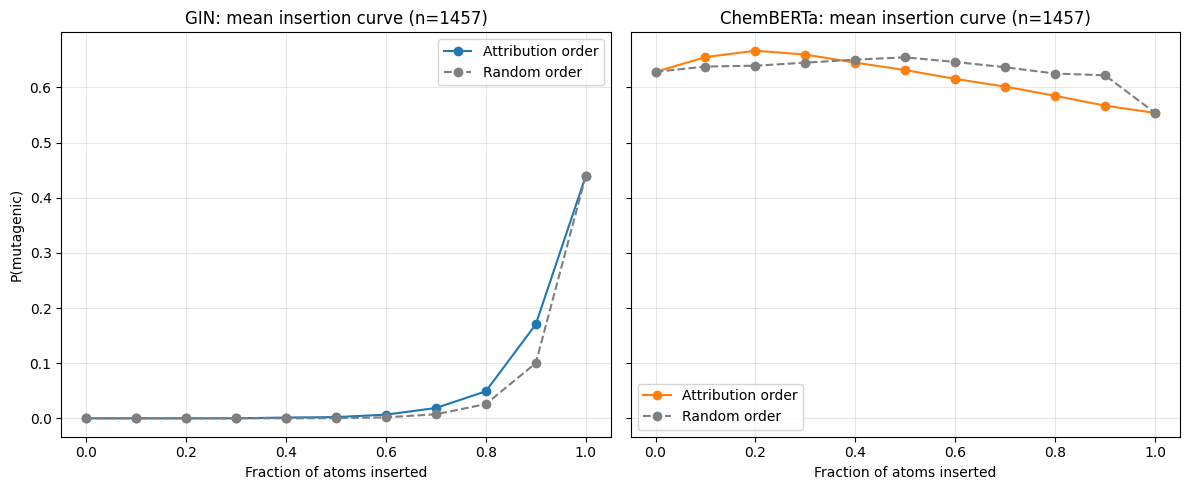


Saved figure to /kaggle/working/insertion_curves_mean.png


In [20]:
import matplotlib.pyplot as plt

n_grid = 11
gin_ins_attr_curves = []
gin_ins_rand_curves = []
cb_ins_attr_curves = []
cb_ins_rand_curves = []

test_drug_ids = list(smiles_by_id.keys())

# Collect insertion curves across the full dataset for both attribution and random orders
for i, drug_id in enumerate(test_drug_ids):
    if drug_id in gin_data_by_id and drug_id in gin_attributions:
        data = gin_data_by_id[drug_id]
        g_scores = gin_attributions[drug_id]
        p_full_g = sigmoid(predict_gin_masked(data, []))
        order_g = full_ranking(g_scores, p_full_g)
        _, _, ins_g = deletion_insertion_curve_gin(data, order_g)
        rng = np.random.RandomState(0)
        rand_order_g = list(rng.permutation(data.x.size(0)))
        _, _, ins_g_r = deletion_insertion_curve_gin(data, rand_order_g)
        gin_ins_attr_curves.append(ins_g)
        gin_ins_rand_curves.append(ins_g_r)

    if drug_id in chemberta_results:
        smiles = smiles_by_id[drug_id]
        c_scores = chemberta_results[drug_id]["atom_scores"]
        p_full_c = sigmoid(predict_chemberta_masked(smiles, [])[0])
        order_c = full_ranking(c_scores, p_full_c)
        _, _, ins_c = deletion_insertion_curve_chemberta(smiles, order_c)
        rng2 = np.random.RandomState(0)
        rand_order_c = list(rng2.permutation(len(c_scores)))
        _, _, ins_c_r = deletion_insertion_curve_chemberta(smiles, rand_order_c)
        cb_ins_attr_curves.append(ins_c)
        cb_ins_rand_curves.append(ins_c_r)

    if (i + 1) % 200 == 0 or (i + 1) == len(test_drug_ids):
        print(f"  {i + 1}/{len(test_drug_ids)}")

# Compute mean curves across all test molecules
fractions = np.linspace(0, 1, n_grid)
gin_attr_mean = np.mean(gin_ins_attr_curves, axis=0)
gin_rand_mean = np.mean(gin_ins_rand_curves, axis=0)
cb_attr_mean = np.mean(cb_ins_attr_curves, axis=0)
cb_rand_mean = np.mean(cb_ins_rand_curves, axis=0)

# Print tabular comparison of mean probabilities across grid points
print(f"\n{'Fraction':>10s} {'GIN attr':>10s} {'GIN rand':>10s} {'GIN diff':>10s} "
      f"{'CB attr':>10s} {'CB rand':>10s} {'CB diff':>10s}")
for j, f in enumerate(fractions):
    print(f"{f:10.1f} {gin_attr_mean[j]:10.4f} {gin_rand_mean[j]:10.4f} "
          f"{gin_attr_mean[j]-gin_rand_mean[j]:10.4f} "
          f"{cb_attr_mean[j]:10.4f} {cb_rand_mean[j]:10.4f} "
          f"{cb_attr_mean[j]-cb_rand_mean[j]:10.4f}")

# Generate and save comparison plot for insertion curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(fractions, gin_attr_mean, marker='o', label='Attribution order', color='tab:blue')
axes[0].plot(fractions, gin_rand_mean, marker='o', label='Random order', color='tab:gray', linestyle='--')
axes[0].set_title('GIN: mean insertion curve (n=1457)')
axes[0].set_xlabel('Fraction of atoms inserted')
axes[0].set_ylabel('P(mutagenic)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fractions, cb_attr_mean, marker='o', label='Attribution order', color='tab:orange')
axes[1].plot(fractions, cb_rand_mean, marker='o', label='Random order', color='tab:gray', linestyle='--')
axes[1].set_title('ChemBERTa: mean insertion curve (n=1457)')
axes[1].set_xlabel('Fraction of atoms inserted')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/insertion_curves_mean.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved figure to /kaggle/working/insertion_curves_mean.png")

# Phase 5E - Direction Confound Test

  300/1457
  600/1457
  900/1457
  1200/1457
  1457/1457

Predicted-mutagenic subgroup: n=858
Predicted-non-mutagenic subgroup: n=599

  Fraction   Pos attr   Pos rand   Pos diff   Neg attr   Neg rand   Neg diff
       0.0     0.6250     0.6250     0.0000     0.3670     0.3670     0.0000
       0.1     0.6926     0.6400     0.0527     0.3990     0.3650     0.0340
       0.2     0.7375     0.6458     0.0916     0.4349     0.3697     0.0652
       0.3     0.7570     0.6601     0.0970     0.4801     0.3767     0.1034
       0.4     0.7689     0.6711     0.0977     0.5325     0.3792     0.1533
       0.5     0.7765     0.6843     0.0922     0.5763     0.3880     0.1883
       0.6     0.7789     0.6862     0.0928     0.6186     0.4112     0.2074
       0.7     0.7818     0.6987     0.0831     0.6569     0.4524     0.2045
       0.8     0.7769     0.7108     0.0661     0.6903     0.4975     0.1928
       0.9     0.7642     0.7466     0.0176     0.7156     0.5564     0.1592
       1.0     0.7

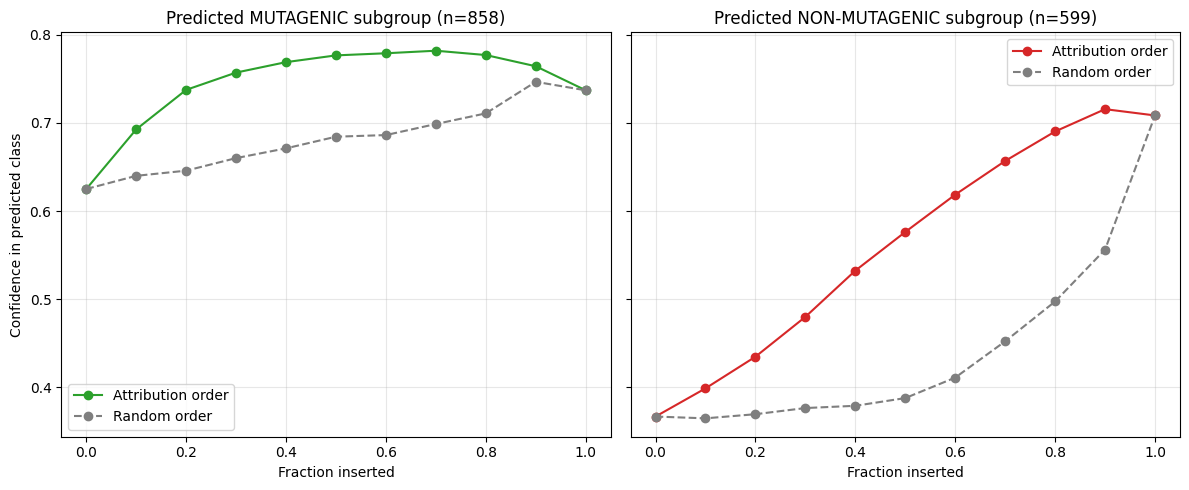


Saved to /kaggle/working/insertion_curves_by_direction.png


In [21]:
# We split ChemBERTa's insertion curve by predicted class, using a direction-corrected "confidence in predicted class" formula.
def to_predicted_class_confidence(p_mutagenic, p_full_mutagenic):
    """Converts raw probability into model confidence for the predicted class.
    
    Higher values consistently represent higher confidence in the model's 
    actual original prediction, regardless of whether it predicted mutagenic or non-mutagenic.
    """
    if p_full_mutagenic > 0.5:
        return p_mutagenic
    else:
        return 1 - p_mutagenic

n_grid = 11
cb_attr_pos, cb_rand_pos = [], []  # Subgroup for molecules predicted as mutagenic
cb_attr_neg, cb_rand_neg = [], []  # Subgroup for molecules predicted as non-mutagenic

test_drug_ids = list(smiles_by_id.keys())

# Iterate through test dataset to compute and partition direction-corrected insertion curves
for i, drug_id in enumerate(test_drug_ids):
    if drug_id not in chemberta_results:
        continue
    smiles = smiles_by_id[drug_id]
    c_scores = chemberta_results[drug_id]["atom_scores"]
    p_full_c = sigmoid(predict_chemberta_masked(smiles, [])[0])
    order_c = full_ranking(c_scores, p_full_c)
    _, _, ins_c = deletion_insertion_curve_chemberta(smiles, order_c)
    
    rng2 = np.random.RandomState(0)
    rand_order_c = list(rng2.permutation(len(c_scores)))
    _, _, ins_c_r = deletion_insertion_curve_chemberta(smiles, rand_order_c)

    # Apply direction correction to every point along both curves
    ins_c_corrected = np.array([to_predicted_class_confidence(p, p_full_c) for p in ins_c])
    ins_c_r_corrected = np.array([to_predicted_class_confidence(p, p_full_c) for p in ins_c_r])

    if p_full_c > 0.5:
        cb_attr_pos.append(ins_c_corrected)
        cb_rand_pos.append(ins_c_r_corrected)
    else:
        cb_attr_neg.append(ins_c_corrected)
        cb_rand_neg.append(ins_c_r_corrected)

    if (i + 1) % 300 == 0 or (i + 1) == len(test_drug_ids):
        print(f"  {i + 1}/{len(test_drug_ids)}")

fractions = np.linspace(0, 1, n_grid)
print(f"\nPredicted-mutagenic subgroup: n={len(cb_attr_pos)}")
print(f"Predicted-non-mutagenic subgroup: n={len(cb_attr_neg)}")

# Compute mean curves across both subgroups
attr_pos_mean = np.mean(cb_attr_pos, axis=0)
rand_pos_mean = np.mean(cb_rand_pos, axis=0)
attr_neg_mean = np.mean(cb_attr_neg, axis=0)
rand_neg_mean = np.mean(cb_rand_neg, axis=0)

# Print tabular breakdown of confidence values across grid points
print(f"\n{'Fraction':>10s} {'Pos attr':>10s} {'Pos rand':>10s} {'Pos diff':>10s} "
      f"{'Neg attr':>10s} {'Neg rand':>10s} {'Neg diff':>10s}")
for j, f in enumerate(fractions):
    print(f"{f:10.1f} {attr_pos_mean[j]:10.4f} {rand_pos_mean[j]:10.4f} "
          f"{attr_pos_mean[j]-rand_pos_mean[j]:10.4f} "
          f"{attr_neg_mean[j]:10.4f} {rand_neg_mean[j]:10.4f} "
          f"{attr_neg_mean[j]-rand_neg_mean[j]:10.4f}")

# Generate and save comparison plot split by predicted direction
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].plot(fractions, attr_pos_mean, marker='o', label='Attribution order', color='tab:green')
axes[0].plot(fractions, rand_pos_mean, marker='o', label='Random order', color='tab:gray', linestyle='--')
axes[0].set_title(f'Predicted MUTAGENIC subgroup (n={len(cb_attr_pos)})')
axes[0].set_xlabel('Fraction inserted')
axes[0].set_ylabel('Confidence in predicted class')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(fractions, attr_neg_mean, marker='o', label='Attribution order', color='tab:red')
axes[1].plot(fractions, rand_neg_mean, marker='o', label='Random order', color='tab:gray', linestyle='--')
axes[1].set_title(f'Predicted NON-MUTAGENIC subgroup (n={len(cb_attr_neg)})')
axes[1].set_xlabel('Fraction inserted')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/insertion_curves_by_direction.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved to /kaggle/working/insertion_curves_by_direction.png")

# Phase 5F - All-corrected (Direction) Full-scale Run

In [22]:
N_RANDOM = 10
FRACTION = 0.2
N_GRID = 11

def to_pcc(p_mutagenic, p_full_mutagenic):
    """Calculates confidence in whatever class was actually predicted."""
    return p_mutagenic if p_full_mutagenic > 0.5 else 1 - p_mutagenic

def compute_all_metrics_gin(data, atom_scores, n_random=N_RANDOM, fraction=FRACTION, n_grid=N_GRID):
    n_atoms = data.x.size(0)
    p_full_raw = sigmoid(predict_gin_masked(data, []))
    p_full = to_pcc(p_full_raw, p_full_raw)

    def cpred(mask_list):
        return to_pcc(sigmoid(predict_gin_masked(data, mask_list)), p_full_raw)

    order = full_ranking(atom_scores, p_full_raw)
    k = max(1, int(np.ceil(n_atoms * fraction)))
    top_k = order[:k]
    complement = [i for i in range(n_atoms) if i not in top_k]

    comp_top = p_full - cpred(top_k)
    suff_top = p_full - cpred(complement)

    rand_comps, rand_suffs = [], []
    for s in range(n_random):
        rng = np.random.RandomState(s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        rand_complement = [i for i in range(n_atoms) if i not in subset]
        rand_comps.append(p_full - cpred(subset))
        rand_suffs.append(p_full - cpred(rand_complement))
    rand_comp_mean = float(np.mean(rand_comps))
    rand_suff_mean = float(np.mean(rand_suffs))

    fractions = np.linspace(0, 1, n_grid)
    del_probs, ins_probs = [], []
    for f in fractions:
        kk = int(round(f * n_atoms))
        prefix = order[:kk]
        comp2 = [i for i in range(n_atoms) if i not in prefix]
        del_probs.append(cpred(prefix))
        ins_probs.append(cpred(comp2))

    rng_o = np.random.RandomState(0)
    random_order = list(rng_o.permutation(n_atoms))
    del_probs_r, ins_probs_r = [], []
    for f in fractions:
        kk = int(round(f * n_atoms))
        prefix = random_order[:kk]
        comp2 = [i for i in range(n_atoms) if i not in prefix]
        del_probs_r.append(cpred(prefix))
        ins_probs_r.append(cpred(comp2))

    del_auc = np.trapz(del_probs, fractions)
    del_auc_r = np.trapz(del_probs_r, fractions)
    ins_auc = np.trapz(ins_probs, fractions)
    ins_auc_r = np.trapz(ins_probs_r, fractions)

    return {
        "comp_corrected": comp_top - rand_comp_mean,
        "suff_corrected": rand_suff_mean - suff_top,
        "del_corrected": del_auc_r - del_auc,
        "ins_corrected": ins_auc - ins_auc_r,
    }

def compute_all_metrics_chemberta(smiles, atom_scores, n_random=N_RANDOM, fraction=FRACTION, n_grid=N_GRID):
    n_atoms = len(atom_scores)
    p_full_raw = sigmoid(predict_chemberta_masked(smiles, [])[0])
    p_full = to_pcc(p_full_raw, p_full_raw)

    def cpred(mask_list):
        return to_pcc(sigmoid(predict_chemberta_masked(smiles, mask_list)[0]), p_full_raw)

    order = full_ranking(atom_scores, p_full_raw)
    k = max(1, int(np.ceil(n_atoms * fraction)))
    top_k = order[:k]
    complement = [i for i in range(n_atoms) if i not in top_k]

    comp_top = p_full - cpred(top_k)
    suff_top = p_full - cpred(complement)

    rand_comps, rand_suffs = [], []
    for s in range(n_random):
        rng = np.random.RandomState(s)
        subset = list(rng.choice(n_atoms, size=k, replace=False))
        rand_complement = [i for i in range(n_atoms) if i not in subset]
        rand_comps.append(p_full - cpred(subset))
        rand_suffs.append(p_full - cpred(rand_complement))
    rand_comp_mean = float(np.mean(rand_comps))
    rand_suff_mean = float(np.mean(rand_suffs))

    fractions = np.linspace(0, 1, n_grid)
    del_probs, ins_probs = [], []
    for f in fractions:
        kk = int(round(f * n_atoms))
        prefix = order[:kk]
        comp2 = [i for i in range(n_atoms) if i not in prefix]
        del_probs.append(cpred(prefix))
        ins_probs.append(cpred(comp2))

    rng_o = np.random.RandomState(0)
    random_order = list(rng_o.permutation(n_atoms))
    del_probs_r, ins_probs_r = [], []
    for f in fractions:
        kk = int(round(f * n_atoms))
        prefix = random_order[:kk]
        comp2 = [i for i in range(n_atoms) if i not in prefix]
        del_probs_r.append(cpred(prefix))
        ins_probs_r.append(cpred(comp2))

    del_auc = np.trapz(del_probs, fractions)
    del_auc_r = np.trapz(del_probs_r, fractions)
    ins_auc = np.trapz(ins_probs, fractions)
    ins_auc_r = np.trapz(ins_probs_r, fractions)

    return {
        "comp_corrected": comp_top - rand_comp_mean,
        "suff_corrected": rand_suff_mean - suff_top,
        "del_corrected": del_auc_r - del_auc,
        "ins_corrected": ins_auc - ins_auc_r,
    }

# Run a quick sanity check on the sample molecule
sample_gin = compute_all_metrics_gin(sample_data, gin_attributions[sample_drug_id])
sample_cb = compute_all_metrics_chemberta(sample_smiles, chemberta_results[sample_drug_id]["atom_scores"])
print("=== Sample molecule sanity check (corrected formula) ===")
print("GIN:      ", sample_gin)
print("ChemBERTa:", sample_cb)
print()

# Execute full test-set loop for both models
test_drug_ids = list(smiles_by_id.keys())
gin_all, cb_all = {}, {}
failed_gin, failed_cb = 0, 0
start = time.time()

for i, drug_id in enumerate(test_drug_ids):
    if drug_id in gin_data_by_id and drug_id in gin_attributions:
        try:
            gin_all[drug_id] = compute_all_metrics_gin(gin_data_by_id[drug_id], gin_attributions[drug_id])
        except Exception:
            failed_gin += 1
    if drug_id in chemberta_results:
        try:
            cb_all[drug_id] = compute_all_metrics_chemberta(
                smiles_by_id[drug_id], chemberta_results[drug_id]["atom_scores"])
        except Exception:
            failed_cb += 1

    if (i + 1) % 100 == 0 or (i + 1) == len(test_drug_ids):
        elapsed = time.time() - start
        print(f"  {i + 1}/{len(test_drug_ids)}  "
              f"(GIN ok: {len(gin_all)}, fail: {failed_gin}; CB ok: {len(cb_all)}, fail: {failed_cb})  "
              f"elapsed: {elapsed:.0f}s")

print(f"\nDone. GIN: {len(gin_all)}/{len(test_drug_ids)}. ChemBERTa: {len(cb_all)}/{len(test_drug_ids)}.")

# Save corrected metric dictionaries to disk via pickle
with open("/kaggle/working/gin_all_metrics_CORRECTED.pkl", "wb") as f:
    pickle.dump(gin_all, f)
with open("/kaggle/working/chemberta_all_metrics_CORRECTED.pkl", "wb") as f:
    pickle.dump(cb_all, f)
print("Saved corrected metric pickles to /kaggle/working/")

# Perform paired statistical comparisons across all four metrics
common_ids = sorted(set(gin_all.keys()) & set(cb_all.keys()))
print(f"\nMolecules with both models: {len(common_ids)}")

for metric in ["comp_corrected", "suff_corrected", "del_corrected", "ins_corrected"]:
    g = np.array([gin_all[i][metric] for i in common_ids])
    c = np.array([cb_all[i][metric] for i in common_ids])
    t, p = stats.ttest_rel(c, g)
    w, wp = stats.wilcoxon(c, g)
    print(f"\n=== {metric} (CORRECTED), n={len(common_ids)} ===")
    print(f"GIN:       mean={g.mean():.4f}  std={g.std():.4f}")
    print(f"ChemBERTa: mean={c.mean():.4f}  std={c.std():.4f}")
    print(f"Paired t-test: t={t:.3f}, p={p:.3e}    Wilcoxon: p={wp:.3e}")

=== Sample molecule sanity check (corrected formula) ===
GIN:       {'comp_corrected': np.float64(5.8597250299885495e-05), 'suff_corrected': np.float64(-1.1102230246251565e-16), 'del_corrected': np.float64(0.00954591479130143), 'ins_corrected': np.float64(0.0033631696157208762)}
ChemBERTa: {'comp_corrected': np.float64(0.04205511296167515), 'suff_corrected': np.float64(0.01855867495642475), 'del_corrected': np.float64(0.0007556865232644094), 'ins_corrected': np.float64(0.0018399997869679163)}

  100/1457  (GIN ok: 100, fail: 0; CB ok: 100, fail: 0)  elapsed: 51s
  200/1457  (GIN ok: 200, fail: 0; CB ok: 200, fail: 0)  elapsed: 100s
  300/1457  (GIN ok: 300, fail: 0; CB ok: 300, fail: 0)  elapsed: 150s
  400/1457  (GIN ok: 400, fail: 0; CB ok: 400, fail: 0)  elapsed: 201s
  500/1457  (GIN ok: 500, fail: 0; CB ok: 500, fail: 0)  elapsed: 251s
  600/1457  (GIN ok: 600, fail: 0; CB ok: 600, fail: 0)  elapsed: 301s
  700/1457  (GIN ok: 700, fail: 0; CB ok: 700, fail: 0)  elapsed: 352s
  800

# Phase 6 - Ground-truth Toxicophore Alignment

In [24]:
GT_PATH = "/kaggle/input/datasets/minoola33/mutagenicity-groundtruth-attributions/attributions.npz"

# Load ground-truth dataset and index by canonical SMILES
gt_data = np.load(GT_PATH, allow_pickle=True)["attributions"]
print(f"Ground-truth molecules: {len(gt_data)}")

gt_lookup = {}
parse_failures = 0
for item in gt_data:
    raw_smiles = item["SMILES"].strip()
    mol = Chem.MolFromSmiles(raw_smiles)
    if mol is None:
        parse_failures += 1
        continue
    canon = Chem.MolToSmiles(mol, canonical=True)
    gt_lookup[canon] = {"mol": mol, "node_atts": item["node_atts"], "label": item["label"]}

print(f"Parse failures: {parse_failures}")
print(f"Unique canonical molecules in lookup: {len(gt_lookup)}")

# Align ground-truth atom attributions to our canonical SMILES representation
def align_ground_truth(our_smiles_canon):
    if our_smiles_canon not in gt_lookup:
        return None
    entry = gt_lookup[our_smiles_canon]
    their_mol = entry["mol"]
    their_atts = entry["node_atts"]
    our_mol = Chem.MolFromSmiles(our_smiles_canon)
    if their_mol.GetNumAtoms() != our_mol.GetNumAtoms():
        return None
    match = our_mol.GetSubstructMatch(their_mol)
    if not match or len(match) != our_mol.GetNumAtoms():
        return None
    aligned = np.zeros(our_mol.GetNumAtoms(), dtype=int)
    for their_idx, our_idx in enumerate(match):
        aligned[our_idx] = their_atts[their_idx]
    return aligned

# Filter test set and construct Drug_ID lookup dictionary for alignment masks
test_df_local2 = df_clean[df_clean['split'] == 'test']
ground_truth_masks = {}
alignment_failures = 0
unmatched_count = 0

for _, row in test_df_local2.iterrows():
    canon = row['Drug_standardized']
    if canon not in gt_lookup:
        unmatched_count += 1
        continue
    mask = align_ground_truth(canon)
    if mask is None:
        alignment_failures += 1
        continue
    ground_truth_masks[row['Drug_ID']] = mask

print(f"\nTest set: {len(test_df_local2)} molecules")
print(f"Matched to ground truth: {len(ground_truth_masks) + alignment_failures} "
      f"({unmatched_count} unmatched)")
print(f"Alignment failures: {alignment_failures}")
print(f"Successfully aligned: {len(ground_truth_masks)} (expect ~1217 based on Phase 2B)")

# Separate test molecules into toxicophore-positive and negative subsets
toxicophore_positive_ids = [did for did, mask in ground_truth_masks.items() if mask.sum() > 0]
toxicophore_negative_ids = [did for did, mask in ground_truth_masks.items() if mask.sum() == 0]

print(f"\nOf {len(ground_truth_masks)} aligned test molecules:")
print(f"  With >=1 true toxicophore atom (usable for IoU/precision/recall): {len(toxicophore_positive_ids)}")
print(f"  With 0 flagged atoms (not usable for this metric): {len(toxicophore_negative_ids)}")

# Run a quick sanity check on TDC labels for the positive subset
pos_labels = [test_df_local2[test_df_local2['Drug_ID'] == did]['Y'].values[0] for did in toxicophore_positive_ids[:20]]
print(f"\nSample of first 20 toxicophore-positive molecules' TDC labels (expect mostly 1/mutagenic): {pos_labels}")

Ground-truth molecules: 6506
Parse failures: 0
Unique canonical molecules in lookup: 6505

Test set: 1457 molecules
Matched to ground truth: 1217 (240 unmatched)
Alignment failures: 0
Successfully aligned: 1217 (expect ~1217 based on Phase 2B)

Of 1217 aligned test molecules:
  With >=1 true toxicophore atom (usable for IoU/precision/recall): 650
  With 0 flagged atoms (not usable for this metric): 567

Sample of first 20 toxicophore-positive molecules' TDC labels (expect mostly 1/mutagenic): [np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)]


In [25]:
# =========================================================
# PHASE 6 — Subset sizing: toxicophore-positive AND TDC-labeled mutagenic
# =========================================================

true_positive_toxicophore_ids = [
    did for did in toxicophore_positive_ids
    if test_df_local2[test_df_local2['Drug_ID'] == did]['Y'].values[0] == 1
]
false_positive_toxicophore_ids = [
    did for did in toxicophore_positive_ids
    if test_df_local2[test_df_local2['Drug_ID'] == did]['Y'].values[0] == 0
]

print(f"Toxicophore-positive AND TDC-labeled mutagenic (primary analysis subset): "
      f"{len(true_positive_toxicophore_ids)}")
print(f"Toxicophore-positive but TDC-labeled non-mutagenic (alert false-positives): "
      f"{len(false_positive_toxicophore_ids)}")
print(f"Total toxicophore-positive (robustness-check subset): {len(toxicophore_positive_ids)}")

Toxicophore-positive AND TDC-labeled mutagenic (primary analysis subset): 479
Toxicophore-positive but TDC-labeled non-mutagenic (alert false-positives): 171
Total toxicophore-positive (robustness-check subset): 650


#### Toxicophore Recovery: IoU vs. Random Baseline




In [26]:
def compute_toxicophore_recovery(atom_scores, gt_mask, n_random=10):
    """Computes IoU and precision/recall relative to ground truth.
    
    atom_scores: signed attribution array where positive values push toward mutagenic.
    gt_mask: binary ground-truth array indicating true toxicophore atoms.
    """
    n_atoms = len(atom_scores)
    k = int(gt_mask.sum())
    if k == 0 or k >= n_atoms:
        return None

    top_k_idx = set(np.argsort(-atom_scores)[:k])
    true_idx = set(np.where(gt_mask == 1)[0])

    intersection = len(top_k_idx & true_idx)
    union = len(top_k_idx | true_idx)
    iou = intersection / union if union > 0 else 0.0
    precision_recall = intersection / k

    # Compute random baseline IoU over multiple permutations
    random_ious = []
    for s in range(n_random):
        rng = np.random.RandomState(s)
        rand_idx = set(rng.choice(n_atoms, size=k, replace=False))
        r_i = len(rand_idx & true_idx)
        r_u = len(rand_idx | true_idx)
        random_ious.append(r_i / r_u if r_u > 0 else 0.0)
    random_iou_mean = float(np.mean(random_ious))

    return {
        "iou": iou,
        "precision_recall": precision_recall,
        "random_iou": random_iou_mean,
        "corrected_iou": iou - random_iou_mean,
        "k": k,
        "n_atoms": n_atoms,
        "top_k_idx": top_k_idx,
        "true_idx": true_idx,
    }

# Run a hand-check evaluation on the first toxicophore-positive molecule
check_id = true_positive_toxicophore_ids[0]
gt_mask_check = ground_truth_masks[check_id]
gin_scores_check = gin_attributions[check_id]
cb_scores_check = chemberta_results[check_id]["atom_scores"]
smiles_check = smiles_by_id[check_id]

print(f"Molecule: {check_id}")
print(f"SMILES: {smiles_check}")
print(f"Atom count -- ground truth: {len(gt_mask_check)}, GIN: {len(gin_scores_check)}, "
      f"ChemBERTa: {len(cb_scores_check)}  (Counts must match across all sources)")

assert len(gt_mask_check) == len(gin_scores_check) == len(cb_scores_check), \
    "Atom count mismatch across sources -- indexing halted."

mol_check = Chem.MolFromSmiles(smiles_check)
print("\nAtom-by-atom comparison:")
print(f"{'Idx':>4s} {'Sym':>4s} {'GT':>4s} {'GIN score':>10s} {'CB score':>10s}")
for i in range(len(gt_mask_check)):
    sym = mol_check.GetAtomWithIdx(i).GetSymbol()
    print(f"{i:4d} {sym:>4s} {gt_mask_check[i]:4d} {gin_scores_check[i]:10.4f} {cb_scores_check[i]:10.4f}")

gin_result = compute_toxicophore_recovery(gin_scores_check, gt_mask_check)
cb_result = compute_toxicophore_recovery(cb_scores_check, gt_mask_check)

print(f"\nTrue toxicophore atoms (k={gin_result['k']}): {sorted(gin_result['true_idx'])}")
print(f"GIN top-k selected:        {sorted(gin_result['top_k_idx'])}")
print(f"GIN IoU: {gin_result['iou']:.4f}  random: {gin_result['random_iou']:.4f}  "
      f"corrected: {gin_result['corrected_iou']:.4f}")

print(f"\nChemBERTa top-k selected: {sorted(cb_result['top_k_idx'])}")
print(f"ChemBERTa IoU: {cb_result['iou']:.4f}  random: {cb_result['random_iou']:.4f}  "
      f"corrected: {cb_result['corrected_iou']:.4f}")

Molecule: Drug 1
SMILES: O=[N+]([O-])c1c2c(c3ccc4cccc5ccc1c3c45)CCCC2
Atom count -- ground truth: 23, GIN: 23, ChemBERTa: 23  (Counts must match across all sources)

Atom-by-atom comparison:
 Idx  Sym   GT  GIN score   CB score
   0    O    1     2.2908    -0.0924
   1    N    1     4.9199    -0.1535
   2    O    1     1.6008     0.0486
   3    C    1     4.3027    -0.0553
   4    C    0     4.5227     0.0585
   5    C    0     4.6110    -0.0042
   6    C    0     4.7809    -0.1525
   7    C    0     3.2208     0.0201
   8    C    0     3.1732     0.0201
   9    C    0     4.3576     0.0201
  10    C    0     3.0238     0.1306
  11    C    0     2.6995     0.1306
  12    C    0     3.0260     0.1306
  13    C    0     4.3569     0.1306
  14    C    0     3.1838     0.0882
  15    C    0     3.2290     0.0882
  16    C    0     4.7721     0.0882
  17    C    0     5.3001     0.0945
  18    C    0     5.1805    -0.0491
  19    C    0     3.1777    -0.0263
  20    C    0     2.6822    -0.

#### Toxicophore recovery: 15-molecule sample check


In [27]:
random.seed(42)
sample_tox_ids = random.sample(true_positive_toxicophore_ids, 15)

print(f"{'Drug_ID':10s} {'k':>3s} {'GIN IoU':>9s} {'GIN rand':>9s} {'GIN corr':>9s} "
      f"{'CB IoU':>9s} {'CB rand':>9s} {'CB corr':>9s}")

gin_corr_list, cb_corr_list = [], []
for did in sample_tox_ids:
    gt = ground_truth_masks[did]
    g_scores = gin_attributions[did]
    c_scores = chemberta_results[did]["atom_scores"]

    g_res = compute_toxicophore_recovery(g_scores, gt)
    c_res = compute_toxicophore_recovery(c_scores, gt)
    if g_res is None or c_res is None:
        continue

    gin_corr_list.append(g_res['corrected_iou'])
    cb_corr_list.append(c_res['corrected_iou'])

    print(f"{did:10s} {g_res['k']:3d} {g_res['iou']:9.4f} {g_res['random_iou']:9.4f} "
          f"{g_res['corrected_iou']:9.4f} {c_res['iou']:9.4f} {c_res['random_iou']:9.4f} "
          f"{c_res['corrected_iou']:9.4f}")

import numpy as np
print(f"\nGIN corrected IoU       -- mean: {np.mean(gin_corr_list):.4f}, std: {np.std(gin_corr_list):.4f}")
print(f"ChemBERTa corrected IoU -- mean: {np.mean(cb_corr_list):.4f}, std: {np.std(cb_corr_list):.4f}")

Drug_ID      k   GIN IoU  GIN rand  GIN corr    CB IoU   CB rand   CB corr
Drug 4384    9    0.6364    0.5621    0.0743    0.6364    0.5621    0.0743
Drug 770     4    0.3333    0.1667    0.1667    0.1429    0.1667   -0.0238
Drug 229     4    0.1429    0.2429   -0.1000    0.1429    0.2429   -0.1000
Drug 4997    4    0.1429    0.1857   -0.0429    0.3333    0.1857    0.1476
Drug 1971    7    0.2727    0.2878   -0.0151    0.5556    0.2878    0.2678
Drug 1625    4    0.3333    0.1714    0.1619    0.3333    0.1714    0.1619
Drug 1494    2    0.0000    0.1000   -0.1000    1.0000    0.1000    0.9000
Drug 934     2    0.0000    0.1667   -0.1667    1.0000    0.1667    0.8333
Drug 4971    4    0.0000    0.1095   -0.1095    0.3333    0.1095    0.2238
Drug 717     4    0.3333    0.0714    0.2619    0.1429    0.0714    0.0714
Drug 4610    4    0.1429    0.1714   -0.0286    0.3333    0.1714    0.1619
Drug 6072    3    0.0000    0.1600   -0.1600    0.2000    0.1600    0.0400
Drug 3645    4    0.1429 

# Phase 6B - Toxicophore Recovery Full-scale Run

In [28]:
gin_tox_results, cb_tox_results = {}, {}

for did in true_positive_toxicophore_ids:
    gt = ground_truth_masks[did]
    g_res = compute_toxicophore_recovery(gin_attributions[did], gt)
    c_res = compute_toxicophore_recovery(chemberta_results[did]["atom_scores"], gt)
    if g_res is not None:
        gin_tox_results[did] = g_res
    if c_res is not None:
        cb_tox_results[did] = c_res

common = sorted(set(gin_tox_results.keys()) & set(cb_tox_results.keys()))
print(f"Molecules scored: {len(common)} / {len(true_positive_toxicophore_ids)}")

gin_corr = np.array([gin_tox_results[d]['corrected_iou'] for d in common])
cb_corr = np.array([cb_tox_results[d]['corrected_iou'] for d in common])

print(f"\nGIN corrected IoU:       mean={gin_corr.mean():.4f}  std={gin_corr.std():.4f}")
print(f"ChemBERTa corrected IoU: mean={cb_corr.mean():.4f}  std={cb_corr.std():.4f}")
t, p = stats.ttest_rel(cb_corr, gin_corr)
w, wp = stats.wilcoxon(cb_corr, gin_corr)
print(f"Paired t-test: t={t:.3f}, p={p:.3e}   Wilcoxon: p={wp:.3e}")

t0, p0 = stats.ttest_1samp(gin_corr, 0)
t0c, p0c = stats.ttest_1samp(cb_corr, 0)
print(f"\nGIN vs zero: t={t0:.3f}, p={p0:.3e}")
print(f"ChemBERTa vs zero: t={t0c:.3f}, p={p0c:.3e}")

with open("/kaggle/working/gin_toxicophore_recovery.pkl", "wb") as f:
    pickle.dump(gin_tox_results, f)
with open("/kaggle/working/chemberta_toxicophore_recovery.pkl", "wb") as f:
    pickle.dump(cb_tox_results, f)
print("\nSaved both pickles to /kaggle/working/")

Molecules scored: 475 / 479

GIN corrected IoU:       mean=0.0960  std=0.2160
ChemBERTa corrected IoU: mean=0.1463  std=0.2151
Paired t-test: t=3.651, p=2.902e-04   Wilcoxon: p=3.736e-04

GIN vs zero: t=9.677, p=2.486e-20
ChemBERTa vs zero: t=14.815, p=4.442e-41

Saved both pickles to /kaggle/working/


# Phase 7A - Distribution Shift Robustness Evaluation

In [29]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem

# Compute Morgan fingerprints for all training-set molecules
train_smiles_list = df_clean[df_clean['split'] == 'train']['Drug_standardized'].tolist()
train_fps = []
for smi in train_smiles_list:
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        train_fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048))
print(f"Train fingerprints computed: {len(train_fps)}")

# Calculate nearest-neighbor Tanimoto similarity for each test molecule
test_nn_similarity = {}
for did, smi in smiles_by_id.items():
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    sims = DataStructs.BulkTanimotoSimilarity(fp, train_fps)
    test_nn_similarity[did] = max(sims) if sims else 0.0

sims_array = np.array(list(test_nn_similarity.values()))
median_sim = float(np.median(sims_array))
print(f"NN similarity -- mean: {sims_array.mean():.3f}, median: {median_sim:.3f}, "
      f"min: {sims_array.min():.3f}, max: {sims_array.max():.3f}")

# Split test molecules into high-similarity (in-distribution) and low-similarity (OOD) sets
high_sim_ids = {did for did, s in test_nn_similarity.items() if s >= median_sim}
low_sim_ids = {did for did, s in test_nn_similarity.items() if s < median_sim}
print(f"High similarity subset (in-distribution-ish): {len(high_sim_ids)}")
print(f"Low similarity subset (novel / OOD): {len(low_sim_ids)}")

# Load pre-computed corrected metrics and toxicophore recovery results
with open("/kaggle/working/gin_all_metrics_CORRECTED.pkl", "rb") as f:
    gin_all = pickle.load(f)
with open("/kaggle/working/chemberta_all_metrics_CORRECTED.pkl", "rb") as f:
    cb_all = pickle.load(f)
with open("/kaggle/working/gin_toxicophore_recovery.pkl", "rb") as f:
    gin_tox = pickle.load(f)
with open("/kaggle/working/chemberta_toxicophore_recovery.pkl", "rb") as f:
    cb_tox = pickle.load(f)

# Define helper function for paired stratified testing across model subsets
def stratified_test(gin_dict, cb_dict, metric_name, id_group, label):
    common = sorted(set(gin_dict.keys()) & set(cb_dict.keys()) & id_group)
    if len(common) < 10:
        print(f"{label}: n={len(common)} -- subgroup too small, skipping.")
        return
    g = np.array([gin_dict[i][metric_name] for i in common])
    c = np.array([cb_dict[i][metric_name] for i in common])
    t, p = stats.ttest_rel(c, g)
    print(f"{label} (n={len(common)}): GIN mean = {g.mean():.4f}, CB mean = {c.mean():.4f}, "
          f"paired t = {t:.3f}, p = {p:.3e}")

# Run stratification analysis for Comprehensiveness
print("\n=== Comprehensiveness, stratified by train-set similarity ===")
stratified_test(gin_all, cb_all, "comp_corrected", high_sim_ids, "HIGH similarity")
stratified_test(gin_all, cb_all, "comp_corrected", low_sim_ids, "LOW similarity (OOD)")

# Run stratification analysis for Toxicophore Recovery IoU
print("\n=== Toxicophore Recovery IoU, stratified by train-set similarity ===")
stratified_test(gin_tox, cb_tox, "corrected_iou", high_sim_ids, "HIGH similarity")
stratified_test(gin_tox, cb_tox, "corrected_iou", low_sim_ids, "LOW similarity (OOD)")

Train fingerprints computed: 5094
NN similarity -- mean: 0.495, median: 0.492, min: 0.143, max: 1.000
High similarity subset (in-distribution-ish): 729
Low similarity subset (novel / OOD): 728

=== Comprehensiveness, stratified by train-set similarity ===
HIGH similarity (n=729): GIN mean = 0.0055, CB mean = 0.1124, paired t = 18.228, p = 1.936e-61
LOW similarity (OOD) (n=728): GIN mean = 0.0228, CB mean = 0.1044, paired t = 12.377, p = 4.587e-32

=== Toxicophore Recovery IoU, stratified by train-set similarity ===
HIGH similarity (n=280): GIN mean = 0.0901, CB mean = 0.1367, paired t = 2.746, p = 6.433e-03
LOW similarity (OOD) (n=195): GIN mean = 0.1045, CB mean = 0.1602, paired t = 2.406, p = 1.708e-02


# Phase 7B - Second Endpoint

In [30]:
from tdc.utils import retrieve_label_name_list

label_list = retrieve_label_name_list('Tox21')
print("Available Tox21 label/assay names:", label_list)

from tdc.single_pred import Tox
data_tox21 = Tox(name='Tox21', label_name=label_list[0])
df_tox21 = data_tox21.get_data(format='df')
print(f"\nLoaded with label_name='{label_list[0]}'")
print(f"Shape: {df_tox21.shape}")
print(df_tox21.head())
print(f"\nLabel balance:\n{df_tox21['Y'].value_counts()}")

Downloading...


Available Tox21 label/assay names: ['NR-AR', 'NR-AR-LBD', 'NR-AhR', 'NR-Aromatase', 'NR-ER', 'NR-ER-LBD', 'NR-PPAR-gamma', 'SR-ARE', 'SR-ATAD5', 'SR-HSE', 'SR-MMP', 'SR-p53']


100%|██████████| 712k/712k [00:00<00:00, 56.8MiB/s]
Loading...
Done!



Loaded with label_name='NR-AR'
Shape: (7265, 3)
    Drug_ID                                  Drug    Y
0   TOX3021          CCOc1ccc2nc(S(N)(=O)=O)sc2c1  0.0
1   TOX3020             CCN1C(=O)NC(c2ccccc2)C1=O  0.0
2   TOX3027       CCCN(CC)C(CC)C(=O)Nc1c(C)cccc1C  0.0
3  TOX20800             CC(O)(P(=O)(O)O)P(=O)(O)O  0.0
4   TOX5110  CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C  0.0

Label balance:
Y
0.0    6956
1.0     309
Name: count, dtype: int64


In [31]:
from tdc.single_pred import Tox
from tdc.utils import retrieve_label_name_list

label_list = retrieve_label_name_list('Tox21')
print(f"{'Label':>15s} {'Total':>7s} {'Positive':>9s} {'% positive':>11s}")

results = []
for label in label_list:
    d = Tox(name='Tox21', label_name=label)
    df = d.get_data(format='df')
    n_total = len(df)
    n_pos = (df['Y'] == 1).sum()
    pct = 100 * n_pos / n_total
    results.append((label, n_total, n_pos, pct))
    print(f"{label:>15s} {n_total:7d} {n_pos:9d} {pct:10.1f}%")

# Sort by most balanced (closest to 50%, but realistically just highest % positive)
results_sorted = sorted(results, key=lambda r: -r[3])
print("\nMost balanced (best candidates), sorted by % positive:")
for label, n_total, n_pos, pct in results_sorted[:5]:
    print(f"  {label}: {n_pos}/{n_total} ({pct:.1f}%)")

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...


          Label   Total  Positive  % positive
          NR-AR    7265       309        4.3%
      NR-AR-LBD    6758       237        3.5%
         NR-AhR    6549       768       11.7%
   NR-Aromatase    5821       300        5.2%
          NR-ER    6193       793       12.8%
      NR-ER-LBD    6955       350        5.0%
  NR-PPAR-gamma    6450       186        2.9%
         SR-ARE    5832       942       16.2%
       SR-ATAD5    7072       264        3.7%


Done!
Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


         SR-HSE    6467       372        5.8%
         SR-MMP    5810       918       15.8%
         SR-p53    6774       423        6.2%

Most balanced (best candidates), sorted by % positive:
  SR-ARE: 942/5832 (16.2%)
  SR-MMP: 918/5810 (15.8%)
  NR-ER: 793/6193 (12.8%)
  NR-AhR: 768/6549 (11.7%)
  SR-p53: 423/6774 (6.2%)


#### Load, Standardize, and Split Tox21 (SR-ARE)

In [33]:
from tdc.single_pred import Tox
from rdkit import Chem
from rdkit.Chem.SaltRemover import SaltRemover
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

# Load Tox21 SR-ARE dataset from TDC
data_tox21 = Tox(name='Tox21', label_name='SR-ARE')
df_tox21 = data_tox21.get_data(format='df')

def generate_scaffold_split(df, smiles_col='Drug', seed=42, frac=(0.7, 0.1, 0.2)):
    """Generates Bemis-Murcko scaffold splits while handling unparseable SMILES gracefully."""
    scaffolds = defaultdict(list)
    for idx, smiles in zip(df.index, df[smiles_col]):
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            continue
        try:
            scaffold = MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)
        except Exception:
            continue
        scaffolds[scaffold].append(idx)

    rng = np.random.RandomState(seed)
    scaffold_groups = list(scaffolds.values())
    rng.shuffle(scaffold_groups)
    scaffold_groups.sort(key=len, reverse=True)

    n_total = sum(len(g) for g in scaffold_groups)
    n_train = int(frac[0] * n_total)
    n_valid = int(frac[1] * n_total)

    train_idx, valid_idx, test_idx = [], [], []
    for group in scaffold_groups:
        if len(train_idx) + len(group) <= n_train:
            train_idx.extend(group)
        elif len(valid_idx) + len(group) <= n_valid:
            valid_idx.extend(group)
        else:
            test_idx.extend(group)

    return df.loc[train_idx], df.loc[valid_idx], df.loc[test_idx]

# Execute scaffold splitting
train_df_t, valid_df_t, test_df_t = generate_scaffold_split(df_tox21, seed=42, frac=(0.7, 0.1, 0.2))
print(f"Scaffold split sizes -- train: {len(train_df_t)}, valid: {len(valid_df_t)}, test: {len(test_df_t)}")
print(f"(Original df_tox21 size: {len(df_tox21)} -- any gap represents unparseable SMILES dropped cleanly)")

# Define canonicalization and salt stripping pipeline
remover_t = SaltRemover()
def standardize_smiles_t(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    mol = remover_t.StripMol(mol, dontRemoveEverything=True)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    try:
        Chem.SanitizeMol(mol)
    except Exception:
        return None
    return Chem.MolToSmiles(mol, canonical=True)

# Standardize SMILES and assign splits
df_tox21['Drug_standardized'] = df_tox21['Drug'].apply(standardize_smiles_t)
df_tox21_clean = df_tox21[df_tox21['Drug_standardized'].notna()].copy()

train_ids_t = set(train_df_t['Drug_ID'])
valid_ids_t = set(valid_df_t['Drug_ID'])
test_ids_t = set(test_df_t['Drug_ID'])
df_tox21_clean['split'] = df_tox21_clean['Drug_ID'].apply(
    lambda i: 'train' if i in train_ids_t else ('valid' if i in valid_ids_t else ('test' if i in test_ids_t else 'unknown')))

print("\nSplit distribution in cleaned DataFrame:")
print(df_tox21_clean['split'].value_counts())
assert (df_tox21_clean['split'] == 'unknown').sum() == 0, "Error: Unassigned split groups found."

# Analyze class balance across splits
print("\nClass balance across splits:")
for s in ['train', 'valid', 'test']:
    sub = df_tox21_clean[df_tox21_clean['split'] == s]
    pos = (sub['Y'] == 1).sum()
    print(f"  {s}: {len(sub)} molecules, {pos} positive ({100 * pos / len(sub):.1f}%)")

# Compute positive class weight using only the training split for downstream handling
train_sub = df_tox21_clean[df_tox21_clean['split'] == 'train']
n_pos = (train_sub['Y'] == 1).sum()
n_neg = (train_sub['Y'] == 0).sum()
pos_weight_value = n_neg / n_pos
print(f"\nTraining set balance: {n_neg} negative, {n_pos} positive -> pos_weight = {pos_weight_value:.2f}")

Found local copy...
Loading...
Done!


Scaffold split sizes -- train: 4077, valid: 582, test: 1166
(Original df_tox21 size: 5832 -- any gap represents unparseable SMILES dropped cleanly)

Split distribution in cleaned DataFrame:
split
train    4077
test     1166
valid     582
Name: count, dtype: int64

Class balance across splits:
  train: 4077 molecules, 547 positive (13.4%)
  valid: 582 molecules, 129 positive (22.2%)
  test: 1166 molecules, 266 positive (22.8%)

Training set balance: 3530 negative, 547 positive -> pos_weight = 6.45


# Phase 7C - Train GIN + ChemBERTa on Tox21/SR-ARE

In [34]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GINConv, global_add_pool
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

device = "cuda" if torch.cuda.is_available() else "cpu"

# =========================================================
# GIN Training Pipeline (Class-Weighted)
# =========================================================
def mol_to_data_t(smiles, label):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None or mol.GetNumAtoms() == 0:
        return None
    atom_feats = [[a.GetAtomicNum(), a.GetDegree(), a.GetFormalCharge(),
                   int(a.GetHybridization()), int(a.GetIsAromatic()), a.GetTotalNumHs()]
                  for a in mol.GetAtoms()]
    x = torch.tensor(atom_feats, dtype=torch.float)
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index += [[i, j], [j, i]]
    edge_index = (torch.tensor(edge_index, dtype=torch.long).t().contiguous()
                  if edge_index else torch.zeros((2, 0), dtype=torch.long))
    return Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.float))

def build_dataset_t(df_subset):
    out = []
    for _, row in df_subset.iterrows():
        d = mol_to_data_t(row['Drug_standardized'], row['Y'])
        if d is not None:
            out.append(d)
    return out

train_data_t = build_dataset_t(df_tox21_clean[df_tox21_clean['split'] == 'train'])
valid_data_t = build_dataset_t(df_tox21_clean[df_tox21_clean['split'] == 'valid'])
test_data_t = build_dataset_t(df_tox21_clean[df_tox21_clean['split'] == 'test'])

train_loader_t = DataLoader(train_data_t, batch_size=64, shuffle=True)
valid_loader_t = DataLoader(valid_data_t, batch_size=128, shuffle=False)
test_loader_t = DataLoader(test_data_t, batch_size=128, shuffle=False)

class GIN(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, num_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()
        for i in range(num_layers):
            mlp = nn.Sequential(nn.Linear(in_dim if i == 0 else hidden_dim, hidden_dim),
                               nn.ReLU(), nn.Linear(hidden_dim, hidden_dim))
            self.convs.append(GINConv(mlp))
            self.bns.append(nn.BatchNorm1d(hidden_dim))
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = global_add_pool(x, batch)
        return self.classifier(x).squeeze(-1)

gin_model_t = GIN(in_dim=6).to(device)
optimizer_t = torch.optim.Adam(gin_model_t.parameters(), lr=1e-3, weight_decay=1e-5)
criterion_t = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value).to(device))

def evaluate_t(loader):
    gin_model_t.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            logits = gin_model_t(batch.x, batch.edge_index, batch.batch)
            all_logits.append(logits.cpu())
            all_labels.append(batch.y.cpu())
    logits = torch.cat(all_logits).numpy()
    labels = torch.cat(all_labels).numpy()
    probs = 1 / (1 + np.exp(-logits))
    preds = (probs >= 0.5).astype(int)
    return {"auroc": roc_auc_score(labels, probs), "auprc": average_precision_score(labels, probs),
            "accuracy": accuracy_score(labels, preds)}

best_val_auroc_t, best_state_t, epochs_since_t = 0, None, 0
PATIENCE = 15
for epoch in range(1, 101):
    gin_model_t.train()
    for batch in train_loader_t:
        batch = batch.to(device)
        optimizer_t.zero_grad()
        logits = gin_model_t(batch.x, batch.edge_index, batch.batch)
        loss = criterion_t(logits, batch.y)
        loss.backward()
        optimizer_t.step()
    val_metrics = evaluate_t(valid_loader_t)
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch}: val_auroc={val_metrics['auroc']:.4f}  val_auprc={val_metrics['auprc']:.4f}")
    if val_metrics['auroc'] > best_val_auroc_t:
        best_val_auroc_t = val_metrics['auroc']
        best_state_t = {k: v.cpu().clone() for k, v in gin_model_t.state_dict().items()}
        epochs_since_t = 0
    else:
        epochs_since_t += 1
        if epochs_since_t >= PATIENCE:
            print(f"Early stopping at epoch {epoch}. Best val_auroc={best_val_auroc_t:.4f}")
            break

gin_model_t.load_state_dict(best_state_t)
gin_test_metrics = evaluate_t(test_loader_t)
print("GIN Tox21/SR-ARE TEST results:", gin_test_metrics)
torch.save(best_state_t, "/kaggle/working/gin_tox21_sr_are.pt")

# =========================================================
# ChemBERTa Training Pipeline (Class-Weighted + LayerNorm Fix)
# =========================================================
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from torch.utils.data import Dataset
from huggingface_hub import hf_hub_download
from transformers import logging as hf_logging

CKPT = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer_t = AutoTokenizer.from_pretrained(CKPT)
hf_logging.set_verbosity_error()
chemberta_model_t = AutoModelForSequenceClassification.from_pretrained(CKPT, num_labels=2).to(device)
hf_logging.set_verbosity_warning()

# Apply verified LayerNorm state dictionary restoration fix
ckpt_file = hf_hub_download(repo_id=CKPT, filename="pytorch_model.bin")
raw_state = torch.load(ckpt_file, map_location="cpu")
model_state = chemberta_model_t.state_dict()
matched_keys = [k for k in raw_state if k in model_state]
with torch.no_grad():
    for k in matched_keys:
        model_state[k].copy_(raw_state[k])
model_roberta_keys = [k for k in model_state if k.startswith("roberta.")]
still_unrestored = [k for k in model_roberta_keys if k not in matched_keys]
print(f"LayerNorm fix: {len(matched_keys)} restored, {len(still_unrestored)} unrestored (expect 0)")
assert len(still_unrestored) == 0, "LayerNorm fix failed -- execution halted."

class SMILESDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.smiles = df['Drug_standardized'].tolist()
        self.labels = df['Y'].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self):
        return len(self.smiles)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.smiles[idx], truncation=True, padding='max_length',
                             max_length=self.max_len, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_ds_t = SMILESDataset(df_tox21_clean[df_tox21_clean['split'] == 'train'], tokenizer_t)
valid_ds_t = SMILESDataset(df_tox21_clean[df_tox21_clean['split'] == 'valid'], tokenizer_t)
test_ds_t = SMILESDataset(df_tox21_clean[df_tox21_clean['split'] == 'test'], tokenizer_t)

class_weights_t = torch.tensor([1.0, pos_weight_value], dtype=torch.float).to(device)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_t)
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics_t(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {"auroc": roc_auc_score(labels, probs), "auprc": average_precision_score(labels, probs),
            "accuracy": accuracy_score(labels, preds)}

args_t = TrainingArguments(
    output_dir="/kaggle/working/chemberta_tox21", num_train_epochs=10,
    per_device_train_batch_size=32, per_device_eval_batch_size=64, learning_rate=2e-5,
    eval_strategy="epoch", save_strategy="epoch", load_best_model_at_end=True,
    metric_for_best_model="auroc", greater_is_better=True, save_total_limit=1,
    logging_steps=50, report_to="none", seed=42,
)

trainer_t = WeightedTrainer(model=chemberta_model_t, args=args_t, train_dataset=train_ds_t,
                            eval_dataset=valid_ds_t, compute_metrics=compute_metrics_t)
trainer_t.train()
cb_test_metrics = trainer_t.evaluate(test_ds_t)
print("ChemBERTa Tox21/SR-ARE TEST results:", cb_test_metrics)

trainer_t.save_model("/kaggle/working/chemberta_tox21_final")
tokenizer_t.save_pretrained("/kaggle/working/chemberta_tox21_final")
print("Saved both models successfully.")

Epoch 1: val_auroc=0.6151  val_auprc=0.3233
Epoch 5: val_auroc=0.6291  val_auprc=0.3417
Epoch 10: val_auroc=0.6483  val_auprc=0.3558
Epoch 15: val_auroc=0.6762  val_auprc=0.3857
Epoch 20: val_auroc=0.6959  val_auprc=0.4168
Epoch 25: val_auroc=0.6620  val_auprc=0.3700
Epoch 30: val_auroc=0.6518  val_auprc=0.3953
Early stopping at epoch 33. Best val_auroc=0.7397
GIN Tox21/SR-ARE TEST results: {'auroc': np.float64(0.6924561403508772), 'auprc': np.float64(0.3750322968597854), 'accuracy': 0.3053173241852487}


config.json:   0%|          | 0.00/501 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/166 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

ChemBERTa Tox21/SR-ARE TEST results: {'eval_loss': 0.6842507123947144, 'eval_auroc': 0.6694778613199666, 'eval_auprc': 0.3741067058756314, 'eval_accuracy': 0.5317324185248714, 'eval_runtime': 2.4342, 'eval_samples_per_second': 479.006, 'eval_steps_per_second': 4.108, 'epoch': 10.0}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved both models successfully.


We need a prediction skew check diagnostic!

In [36]:
# --- GIN ---
gin_model_t.eval()
gin_probs = []
for d in test_data_t:
    d = d.to(device)
    batch = torch.zeros(d.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logit = gin_model_t(d.x, d.edge_index, batch).item()
    gin_probs.append(1 / (1 + np.exp(-logit)))
gin_probs = np.array(gin_probs)

print(f"GIN test set: {len(gin_probs)} molecules")
print(f"  Predicted positive (P>0.5): {(gin_probs > 0.5).sum()} ({100*(gin_probs>0.5).mean():.1f}%)")
print(f"  Mean P: {gin_probs.mean():.4f}, median P: {np.median(gin_probs):.4f}")
print(f"  Distribution -- min: {gin_probs.min():.4f}, 25th pct: {np.percentile(gin_probs,25):.4f}, "
      f"75th pct: {np.percentile(gin_probs,75):.4f}, max: {gin_probs.max():.4f}")

# --- ChemBERTa ---
chemberta_model_t.eval()
cb_probs = []
test_df_t_check = df_tox21_clean[df_tox21_clean['split'] == 'test']
for _, row in test_df_t_check.iterrows():
    enc = tokenizer_t(row['Drug_standardized'], return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        logits = chemberta_model_t(**enc).logits
    prob = torch.softmax(logits, dim=1)[0, 1].item()
    cb_probs.append(prob)
cb_probs = np.array(cb_probs)

print(f"\nChemBERTa test set: {len(cb_probs)} molecules")
print(f"  Predicted positive (P>0.5): {(cb_probs > 0.5).sum()} ({100*(cb_probs>0.5).mean():.1f}%)")
print(f"  Mean P: {cb_probs.mean():.4f}, median P: {np.median(cb_probs):.4f}")
print(f"  Distribution -- min: {cb_probs.min():.4f}, 25th pct: {np.percentile(cb_probs,25):.4f}, "
      f"75th pct: {np.percentile(cb_probs,75):.4f}, max: {cb_probs.max():.4f}")

print(f"\nTrue positive rate in test set: {100*test_df_t_check['Y'].mean():.1f}% (for reference)")

GIN test set: 1166 molecules
  Predicted positive (P>0.5): 1050 (90.1%)
  Mean P: 0.7897, median P: 0.8517
  Distribution -- min: 0.0123, 25th pct: 0.7050, 75th pct: 0.9380, max: 1.0000

ChemBERTa test set: 1166 molecules
  Predicted positive (P>0.5): 698 (59.9%)
  Mean P: 0.5503, median P: 0.6015
  Distribution -- min: 0.0125, 25th pct: 0.3130, 75th pct: 0.7949, max: 0.9719

True positive rate in test set: 22.8% (for reference)


# Phase 7D - Attribution Extraction & Corrected Comprehensiveness on Tox21/SR-ARE

In [35]:
from captum.attr import LayerIntegratedGradients

gin_model_t.eval()
chemberta_model_t.eval()

# --- GIN Manual Integrated Gradients Implementation ---
def get_gin_atom_attributions_t(data, n_steps=50):
    data = data.to(device)
    x = data.x.clone()
    baseline = torch.zeros_like(x)
    batch = torch.zeros(x.size(0), dtype=torch.long, device=device)
    edge_index = data.edge_index
    diff = x - baseline
    total_grads = torch.zeros_like(x)
    for step in range(1, n_steps + 1):
        alpha = step / n_steps
        x_interp = (baseline + alpha * diff).clone().requires_grad_(True)
        output = gin_model_t(x_interp, edge_index, batch)
        grad = torch.autograd.grad(output, x_interp)[0]
        total_grads += grad
    avg_grads = total_grads / n_steps
    attributions = diff * avg_grads
    return attributions.sum(dim=1).detach().cpu().numpy()

def predict_gin_masked_t(data, atom_indices_to_mask):
    data = data.to(device)
    x_masked = data.x.clone()
    if len(atom_indices_to_mask) > 0:
        x_masked[list(atom_indices_to_mask), :] = 0.0
    batch = torch.zeros(x_masked.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        return gin_model_t(x_masked, data.edge_index, batch).item()

# --- ChemBERTa LayerIntegratedGradients Setup ---
def chemberta_forward_t(input_ids, attention_mask):
    return chemberta_model_t(input_ids=input_ids, attention_mask=attention_mask).logits

lig_t = LayerIntegratedGradients(chemberta_forward_t, chemberta_model_t.roberta.embeddings)

def get_chemberta_token_attributions_t(smiles, target_class=1, n_steps=50, max_length=128):
    encoded = tokenizer_t(smiles, return_tensors="pt", return_offsets_mapping=True,
                          truncation=True, max_length=max_length)
    offsets = encoded.pop("offset_mapping")[0].tolist()
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    real_len = int(attention_mask.sum().item())
    baseline_ids = torch.full_like(input_ids, tokenizer_t.pad_token_id)
    baseline_ids[0, 0] = input_ids[0, 0]
    baseline_ids[0, real_len - 1] = input_ids[0, real_len - 1]
    attributions, delta = lig_t.attribute(
        inputs=input_ids, baselines=baseline_ids, additional_forward_args=(attention_mask,),
        target=target_class, n_steps=n_steps, return_convergence_delta=True)
    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    tokens = tokenizer_t.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    return tokens[:real_len], token_scores[:real_len], offsets[:real_len]

def predict_chemberta_masked_t(smiles, atom_indices_to_mask, max_length=128):
    encoded = tokenizer_t(smiles, return_tensors="pt", return_offsets_mapping=True,
                          truncation=True, max_length=max_length)
    offsets = encoded.pop("offset_mapping")[0].tolist()
    input_ids = encoded["input_ids"].to(device)
    attention_mask = encoded["attention_mask"].to(device)
    real_len = int(attention_mask.sum().item())
    real_offsets = offsets[:real_len]
    spans = get_atom_char_spans(smiles)
    tok_positions, _ = get_tokens_to_mask(atom_indices_to_mask, spans, real_offsets)
    input_ids_masked = input_ids.clone()
    for pos in tok_positions:
        input_ids_masked[0, pos] = tokenizer_t.pad_token_id
    with torch.no_grad():
        logits = chemberta_model_t(input_ids=input_ids_masked, attention_mask=attention_mask).logits
    return logits[0, 1].item()

def full_atom_pipeline_t(smiles, n_steps=50):
    tokens, scores, offsets = get_chemberta_token_attributions_t(smiles, n_steps=n_steps)
    mol = Chem.MolFromSmiles(smiles)
    spans = get_atom_char_spans(smiles)
    if mol.GetNumAtoms() != len(spans):
        return None
    result = align_tokens_to_atoms(tokens, scores, offsets, spans)
    return result["atom_scores"]

# --- Sample Molecules from Tox21 Test Set ---
random.seed(42)
test_df_t_local = df_tox21_clean[df_tox21_clean['split'] == 'test'].reset_index(drop=True)
sample_size = min(300, len(test_df_t_local))
sample_rows = test_df_t_local.sample(n=sample_size, random_state=42)

gin_data_by_id_t = {row['Drug_ID']: mol_to_data_t(row['Drug_standardized'], row['Y'])
                    for _, row in sample_rows.iterrows()}
gin_data_by_id_t = {k: v for k, v in gin_data_by_id_t.items() if v is not None}
smiles_by_id_t = {row['Drug_ID']: row['Drug_standardized'] for _, row in sample_rows.iterrows()}

def to_pcc_t(p_mutagenic, p_full_mutagenic):
    return p_mutagenic if p_full_mutagenic > 0.5 else 1 - p_mutagenic

def sigmoid_t(x):
    return 1 / (1 + np.exp(-x))

gin_comp_t, cb_comp_t = [], []
failed = 0

print(f"Beginning evaluation on {len(gin_data_by_id_t)} sampled Tox21 test molecules...")

for i, did in enumerate(gin_data_by_id_t.keys()):
    try:
        data = gin_data_by_id_t[did]
        smi = smiles_by_id_t[did]
        n_atoms = data.x.size(0)

        # GIN evaluation
        g_scores = get_gin_atom_attributions_t(data)
        p_full_g = sigmoid_t(predict_gin_masked_t(data, []))
        order_g = full_ranking(g_scores, p_full_g)
        k = max(1, int(np.ceil(n_atoms * 0.2)))
        top_k_g = order_g[:k]
        p_removed_g = to_pcc_t(sigmoid_t(predict_gin_masked_t(data, top_k_g)), p_full_g)
        comp_top_g = to_pcc_t(p_full_g, p_full_g) - p_removed_g
        
        rng = np.random.RandomState(0)
        rand_subset_g = list(rng.choice(n_atoms, size=k, replace=False))
        p_rand_g = to_pcc_t(sigmoid_t(predict_gin_masked_t(data, rand_subset_g)), p_full_g)
        rand_comp_g = to_pcc_t(p_full_g, p_full_g) - p_rand_g
        gin_comp_t.append(comp_top_g - rand_comp_g)

        # ChemBERTa evaluation
        c_scores = full_atom_pipeline_t(smi)
        if c_scores is None:
            continue
        p_full_c = sigmoid_t(predict_chemberta_masked_t(smi, []))
        order_c = full_ranking(c_scores, p_full_c)
        n_atoms_c = len(c_scores)
        k_c = max(1, int(np.ceil(n_atoms_c * 0.2)))
        top_k_c = order_c[:k_c]
        p_removed_c = to_pcc_t(sigmoid_t(predict_chemberta_masked_t(smi, top_k_c)), p_full_c)
        comp_top_c = to_pcc_t(p_full_c, p_full_c) - p_removed_c
        
        rng2 = np.random.RandomState(0)
        rand_subset_c = list(rng2.choice(n_atoms_c, size=k_c, replace=False))
        p_rand_c = to_pcc_t(sigmoid_t(predict_chemberta_masked_t(smi, rand_subset_c)), p_full_c)
        rand_comp_c = to_pcc_t(p_full_c, p_full_c) - p_rand_c
        cb_comp_t.append(comp_top_c - rand_comp_c)

    except Exception:
        failed += 1

    if (i + 1) % 50 == 0:
        print(f"  Processed {i + 1}/{len(gin_data_by_id_t)} molecules (failed: {failed})")

gin_comp_t = np.array(gin_comp_t)
cb_comp_t = np.array(cb_comp_t)
print(f"\nScored successfully: GIN = {len(gin_comp_t)}, ChemBERTa = {len(cb_comp_t)}, failed = {failed}")
print(f"\nGIN comprehensiveness (corrected):        mean = {gin_comp_t.mean():.4f}, std = {gin_comp_t.std():.4f}")
print(f"ChemBERTa comprehensiveness (corrected):  mean = {cb_comp_t.mean():.4f}, std = {cb_comp_t.std():.4f}")

n_common = min(len(gin_comp_t), len(cb_comp_t))
t, p = stats.ttest_rel(cb_comp_t[:n_common], gin_comp_t[:n_common])
w, wp = stats.wilcoxon(cb_comp_t[:n_common], gin_comp_t[:n_common])
print(f"\nPaired t-test: t = {t:.3f}, p = {p:.3e}    Wilcoxon test: p = {wp:.3e}")
print("\n=== SECOND-ENDPOINT VALIDATION RESULT (Tox21/SR-ARE) ===")
print("Compare direction and statistical significance to the primary AMES comprehensiveness results.")

Beginning evaluation on 300 sampled Tox21 test molecules...
  Processed 50/300 molecules (failed: 0)
  Processed 100/300 molecules (failed: 0)
  Processed 150/300 molecules (failed: 0)
  Processed 200/300 molecules (failed: 0)
  Processed 250/300 molecules (failed: 0)
  Processed 300/300 molecules (failed: 0)

Scored successfully: GIN = 300, ChemBERTa = 300, failed = 0

GIN comprehensiveness (corrected):        mean = -0.0075, std = 0.2753
ChemBERTa comprehensiveness (corrected):  mean = 0.0505, std = 0.1197

Paired t-test: t = 3.316, p = 1.026e-03    Wilcoxon test: p = 1.102e-03

=== SECOND-ENDPOINT VALIDATION RESULT (Tox21/SR-ARE) ===
Compare direction and statistical significance to the primary AMES comprehensiveness results.


In [37]:
import shutil
shutil.make_archive("/kaggle/working/chemberta_tox21_final", 'zip', "/kaggle/working/chemberta_tox21_final")

from IPython.display import FileLink
import os
os.chdir('/kaggle/working')
FileLink('chemberta_tox21_final.zip')

/kaggle/working/chemberta_tox21_final.zip

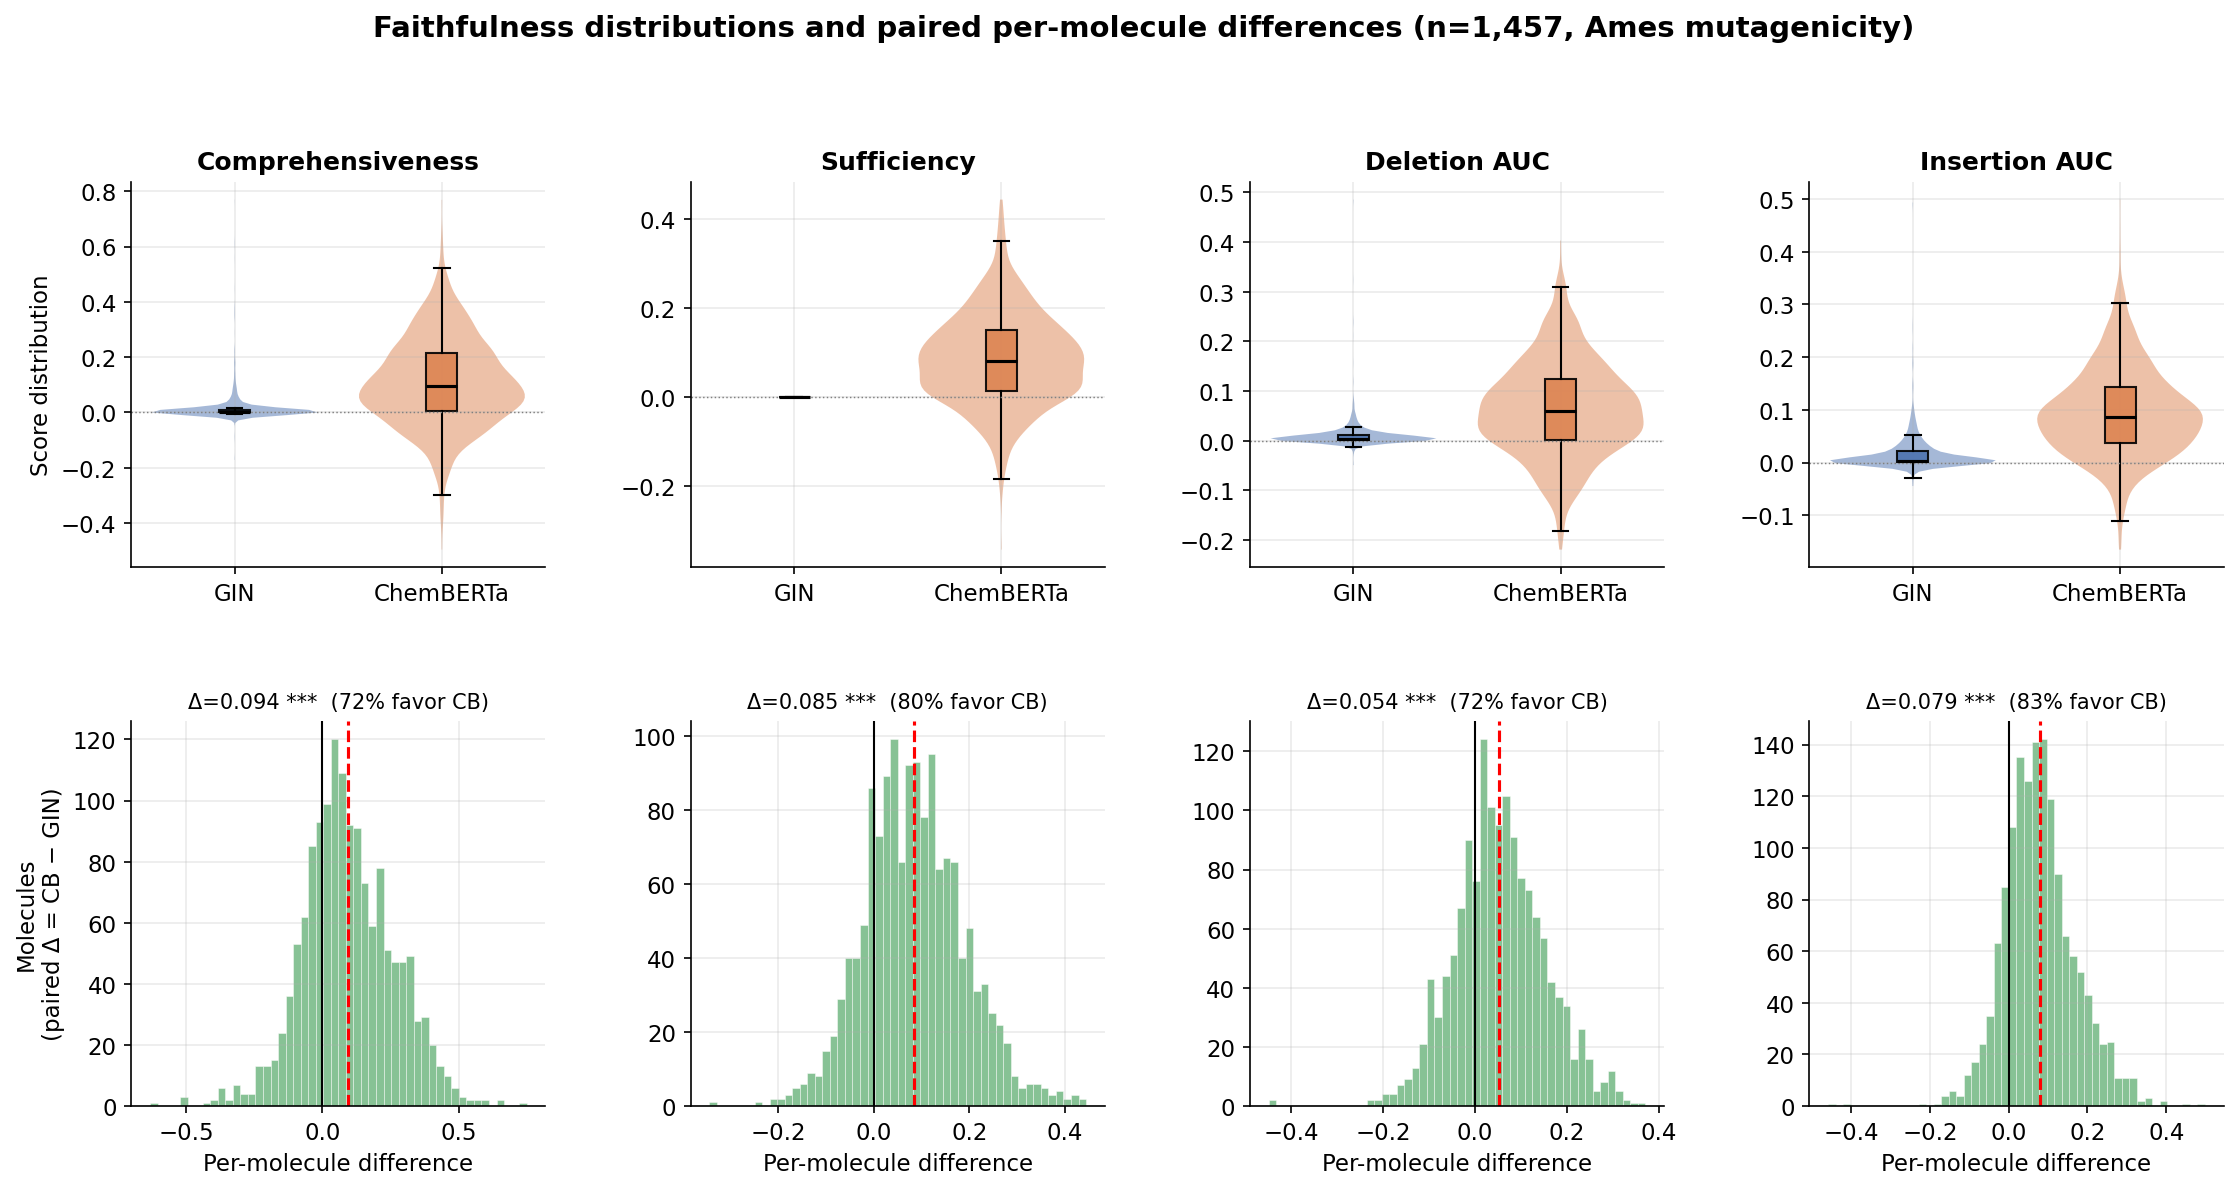

Saved fig1_headline_distributions.png


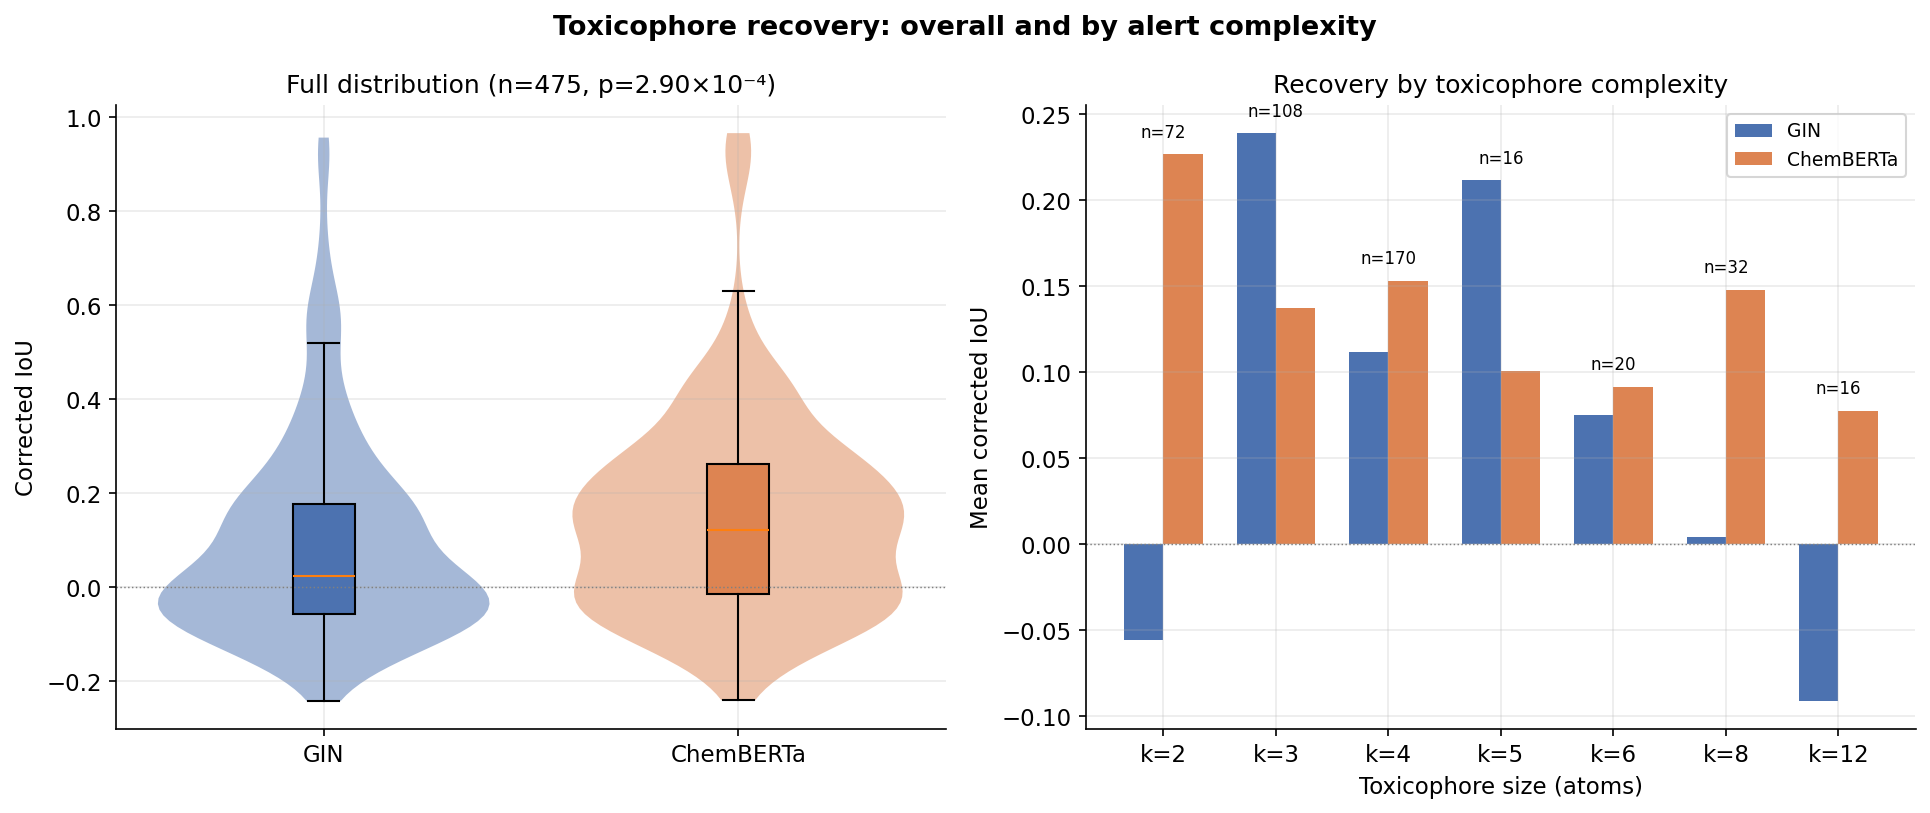

Saved fig2_toxicophore_recovery_detailed.png

--- Figures 1-2 done. Figure 3 (continuous distribution-shift trend) requires recomputing molecular similarity -- see next cell. ---


In [39]:
# =========================================================
# WRITE-UP FIGURES — v2, publication-quality.
# Each figure shows distributions (not just means), paired
# per-molecule structure where relevant, and is designed to
# carry real analytical weight, not just report a summary stat.
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
import os
from scipy import stats

os.makedirs("/kaggle/working/figures", exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "font.family": "sans-serif",
})
GIN_COLOR, CB_COLOR, DIFF_COLOR = "#4C72B0", "#DD8452", "#55A868"

def sem(arr):
    return np.std(arr) / np.sqrt(len(arr))

def ci95(arr):
    return 1.96 * sem(arr)

# =========================================================
# FIGURE 1 — Full distributions + paired per-molecule differences,
# all four AMES metrics. 2 rows x 4 cols: top = raw distributions
# (violin+box), bottom = paired-difference histograms (the thing
# the significance test actually measures).
# =========================================================
with open("/kaggle/working/gin_all_metrics_CORRECTED.pkl", "rb") as f:
    gin_all = pickle.load(f)
with open("/kaggle/working/chemberta_all_metrics_CORRECTED.pkl", "rb") as f:
    cb_all = pickle.load(f)

metrics = ["comp_corrected", "suff_corrected", "del_corrected", "ins_corrected"]
metric_labels = ["Comprehensiveness", "Sufficiency", "Deletion AUC", "Insertion AUC"]
p_values = [5.84e-88, 4.41e-162, 1.72e-84, 1.22e-175]

common_ids = sorted(set(gin_all.keys()) & set(cb_all.keys()))

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.4, wspace=0.35)

for j, (m, label, p) in enumerate(zip(metrics, metric_labels, p_values)):
    g = np.array([gin_all[i][m] for i in common_ids])
    c = np.array([cb_all[i][m] for i in common_ids])
    diff = c - g

    # --- Top: violin + box, raw distributions ---
    ax_top = fig.add_subplot(gs[0, j])
    parts = ax_top.violinplot([g, c], positions=[0, 1], showmeans=False, showextrema=False, widths=0.8)
    for pc, color in zip(parts['bodies'], [GIN_COLOR, CB_COLOR]):
        pc.set_facecolor(color); pc.set_alpha(0.5)
    bp = ax_top.boxplot([g, c], positions=[0, 1], widths=0.15, patch_artist=True,
                         showfliers=False, medianprops=dict(color='black', linewidth=1.5))
    for patch, color in zip(bp['boxes'], [GIN_COLOR, CB_COLOR]):
        patch.set_facecolor(color); patch.set_alpha(0.9)
    ax_top.set_xticks([0, 1]); ax_top.set_xticklabels(["GIN", "ChemBERTa"])
    ax_top.axhline(0, color='gray', linewidth=0.7, linestyle=':')
    ax_top.set_title(f"{label}", fontweight='bold')
    if j == 0:
        ax_top.set_ylabel("Score distribution")

    # --- Bottom: paired difference histogram (CB - GIN per molecule) ---
    ax_bot = fig.add_subplot(gs[1, j])
    ax_bot.hist(diff, bins=50, color=DIFF_COLOR, alpha=0.7, edgecolor='white', linewidth=0.3)
    ax_bot.axvline(0, color='black', linewidth=1)
    ax_bot.axvline(diff.mean(), color='red', linestyle='--', linewidth=1.5)
    pct_positive = 100 * (diff > 0).mean()
    stars = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "n.s."))
    ax_bot.set_title(f"\u0394={diff.mean():.3f} {stars}  ({pct_positive:.0f}% favor CB)", fontsize=10)
    if j == 0:
        ax_bot.set_ylabel("Molecules\n(paired \u0394 = CB \u2212 GIN)")
    ax_bot.set_xlabel("Per-molecule difference")

fig.suptitle("Faithfulness distributions and paired per-molecule differences (n=1,457, Ames mutagenicity)",
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig("/kaggle/working/figures/fig1_headline_distributions.png", bbox_inches='tight')
plt.show()
print("Saved fig1_headline_distributions.png")

# =========================================================
# FIGURE 2 — Toxicophore recovery: distribution + breakdown by
# alert size (k), since a single IoU number hides whether recovery
# is easier/harder for small vs large toxicophores.
# =========================================================
with open("/kaggle/working/gin_toxicophore_recovery.pkl", "rb") as f:
    gin_tox = pickle.load(f)
with open("/kaggle/working/chemberta_toxicophore_recovery.pkl", "rb") as f:
    cb_tox = pickle.load(f)

common_tox = sorted(set(gin_tox.keys()) & set(cb_tox.keys()))
g_iou = np.array([gin_tox[i]['corrected_iou'] for i in common_tox])
c_iou = np.array([cb_tox[i]['corrected_iou'] for i in common_tox])
k_vals = np.array([gin_tox[i]['k'] for i in common_tox])

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# Left: distribution
parts = axes[0].violinplot([g_iou, c_iou], positions=[0, 1], showextrema=False, widths=0.8)
for pc, color in zip(parts['bodies'], [GIN_COLOR, CB_COLOR]):
    pc.set_facecolor(color); pc.set_alpha(0.5)
bp = axes[0].boxplot([g_iou, c_iou], positions=[0, 1], widths=0.15, patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'], [GIN_COLOR, CB_COLOR]):
    patch.set_facecolor(color)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["GIN", "ChemBERTa"])
axes[0].axhline(0, color='gray', linewidth=0.7, linestyle=':')
axes[0].set_ylabel("Corrected IoU")
axes[0].set_title(f"Full distribution (n={len(common_tox)}, p=2.90\u00d710\u207b\u2074)")

# Right: mean corrected IoU by toxicophore size k, with sample counts
k_bins = sorted(set(k_vals))
k_bins_use = [k for k in k_bins if (k_vals == k).sum() >= 15]  # only bins with enough data
g_by_k = [g_iou[k_vals == k].mean() for k in k_bins_use]
c_by_k = [c_iou[k_vals == k].mean() for k in k_bins_use]
n_by_k = [int((k_vals == k).sum()) for k in k_bins_use]

x = np.arange(len(k_bins_use))
width = 0.35
axes[1].bar(x - width/2, g_by_k, width, label="GIN", color=GIN_COLOR)
axes[1].bar(x + width/2, c_by_k, width, label="ChemBERTa", color=CB_COLOR)
for i, n in enumerate(n_by_k):
    axes[1].text(i, max(g_by_k[i], c_by_k[i]) + 0.01, f"n={n}", ha='center', fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels([f"k={k}" for k in k_bins_use])
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle=':')
axes[1].set_xlabel("Toxicophore size (atoms)")
axes[1].set_ylabel("Mean corrected IoU")
axes[1].set_title("Recovery by toxicophore complexity")
axes[1].legend()

fig.suptitle("Toxicophore recovery: overall and by alert complexity", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig2_toxicophore_recovery_detailed.png", bbox_inches='tight')
plt.show()
print("Saved fig2_toxicophore_recovery_detailed.png")

print("\n--- Figures 1-2 done. Figure 3 (continuous distribution-shift trend) "
      "requires recomputing molecular similarity -- see next cell. ---")

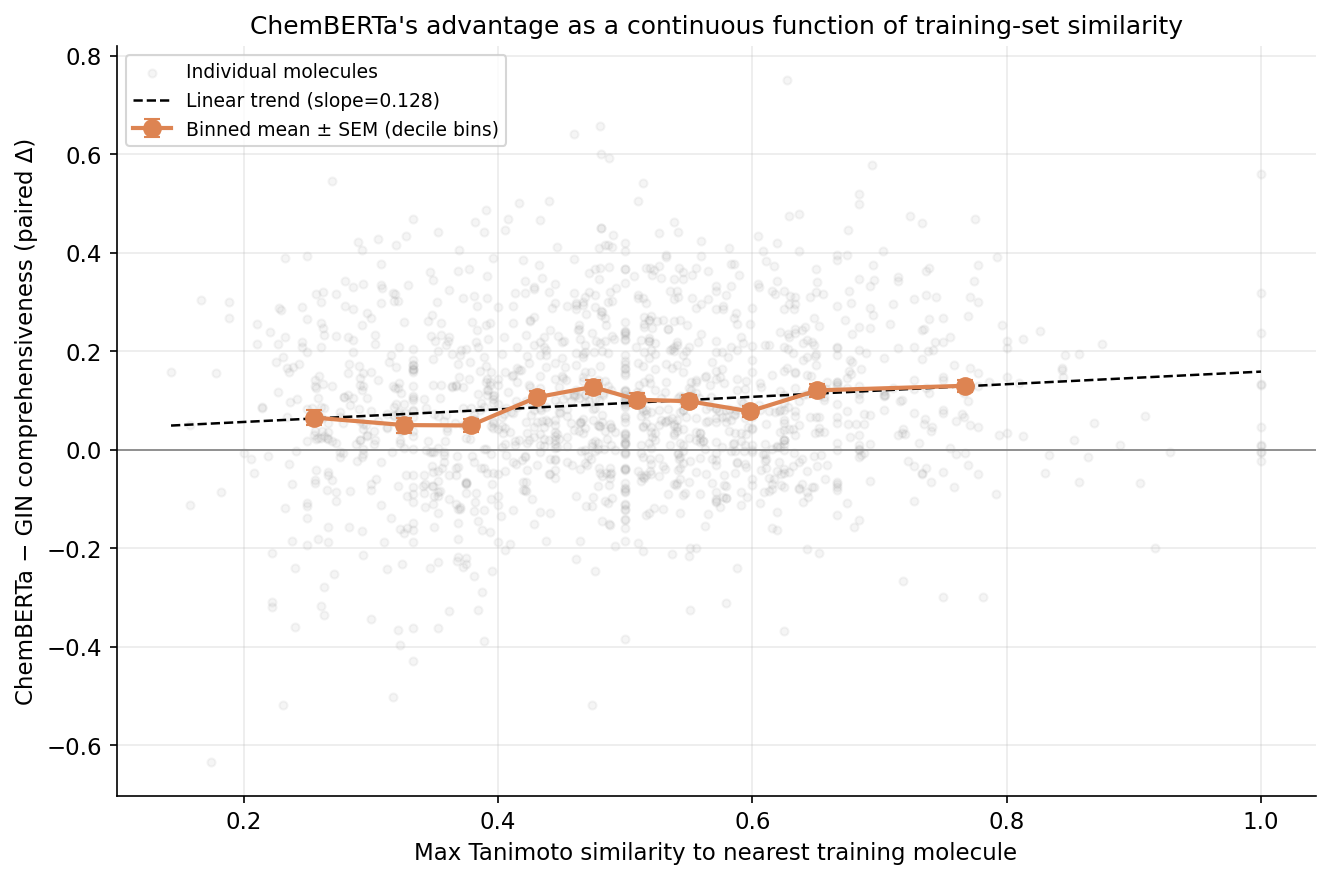

Saved fig3_continuous_distribution_shift.png
Correlation between similarity and CB advantage: r=0.115 (near-zero/flat = advantage is stable across the similarity range)


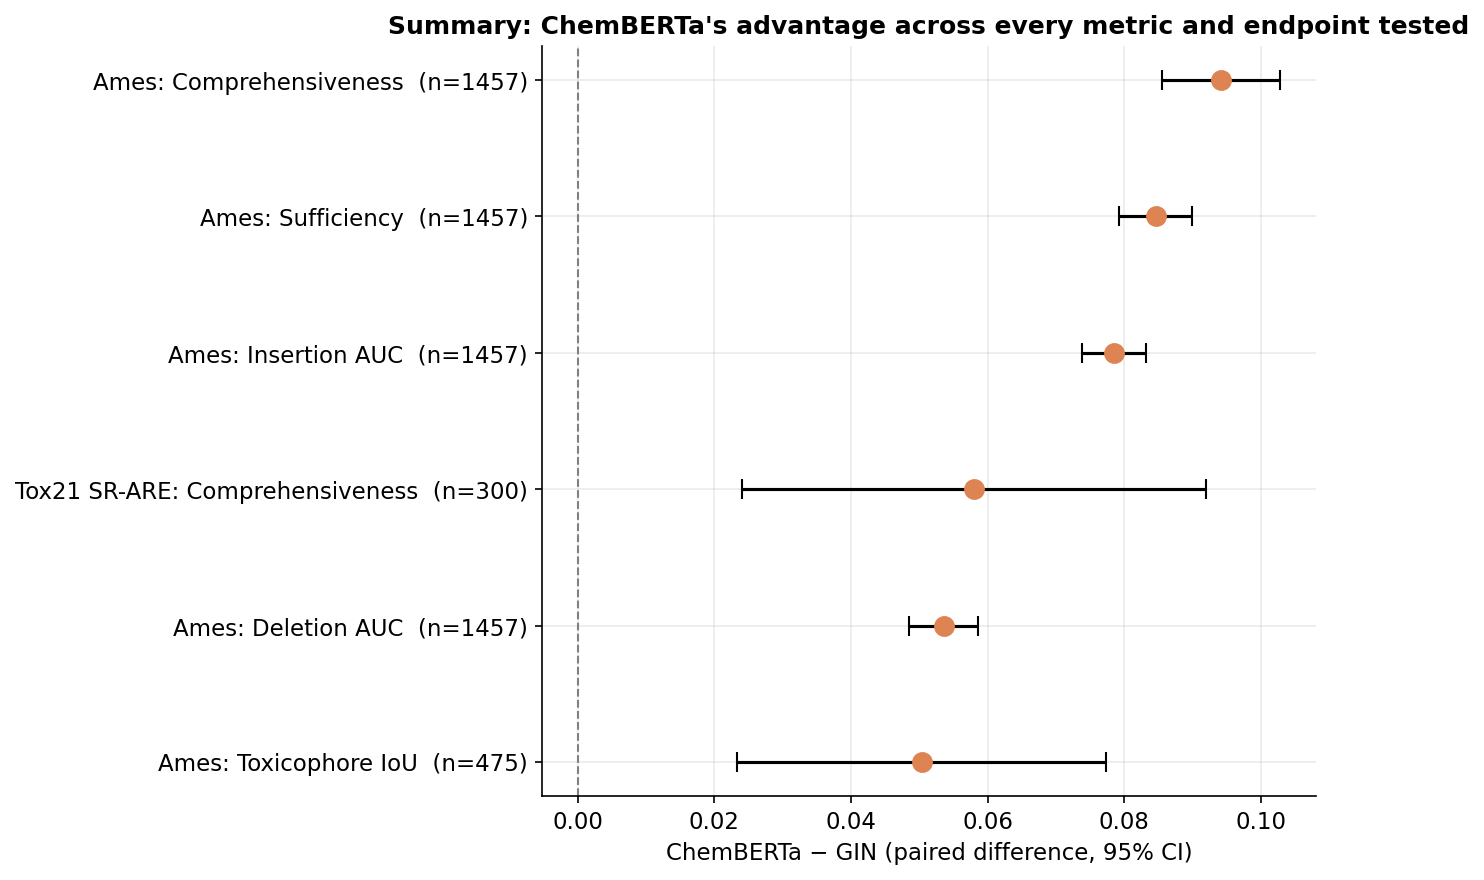

Saved fig4_forest_plot_summary.png


In [40]:
# =========================================================
# WRITE-UP FIGURES — v2, part 2.
# =========================================================

import matplotlib.pyplot as plt
import numpy as np
import pickle
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from sklearn.metrics import roc_curve, roc_auc_score

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
GIN_COLOR, CB_COLOR = "#4C72B0", "#DD8452"

# =========================================================
# FIGURE 3 — Continuous distribution-shift trend (not a crude 2-bin
# split): comprehensiveness advantage (CB - GIN) as a smooth function
# of train-set similarity, with a binned trend line + raw scatter.
# =========================================================
train_smiles_list = df_clean[df_clean['split'] == 'train']['Drug_standardized'].tolist()
train_fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(s), radius=2, nBits=2048)
             for s in train_smiles_list if Chem.MolFromSmiles(s) is not None]

with open("/kaggle/working/gin_all_metrics_CORRECTED.pkl", "rb") as f:
    gin_all = pickle.load(f)
with open("/kaggle/working/chemberta_all_metrics_CORRECTED.pkl", "rb") as f:
    cb_all = pickle.load(f)

common_ids = sorted(set(gin_all.keys()) & set(cb_all.keys()))
sim_vals, diff_vals = [], []
for did in common_ids:
    smi = smiles_by_id[did]
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        continue
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    sim = max(DataStructs.BulkTanimotoSimilarity(fp, train_fps))
    sim_vals.append(sim)
    diff_vals.append(cb_all[did]['comp_corrected'] - gin_all[did]['comp_corrected'])

sim_vals = np.array(sim_vals)
diff_vals = np.array(diff_vals)

# Binned trend (10 quantile bins, not 2 crude halves)
n_bins = 10
bin_edges = np.quantile(sim_vals, np.linspace(0, 1, n_bins + 1))
bin_centers, bin_means, bin_sems = [], [], []
for i in range(n_bins):
    mask = (sim_vals >= bin_edges[i]) & (sim_vals <= bin_edges[i + 1])
    if mask.sum() > 5:
        bin_centers.append(sim_vals[mask].mean())
        bin_means.append(diff_vals[mask].mean())
        bin_sems.append(diff_vals[mask].std() / np.sqrt(mask.sum()))

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(sim_vals, diff_vals, alpha=0.08, color='gray', s=15, label='Individual molecules')
ax.errorbar(bin_centers, bin_means, yerr=bin_sems, marker='o', markersize=8,
            color=CB_COLOR, linewidth=2, capsize=4, label='Binned mean \u00b1 SEM (decile bins)')
z = np.polyfit(sim_vals, diff_vals, 1)
trend_x = np.linspace(sim_vals.min(), sim_vals.max(), 100)
ax.plot(trend_x, np.polyval(z, trend_x), '--', color='black', linewidth=1.2,
        label=f'Linear trend (slope={z[0]:.3f})')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel("Max Tanimoto similarity to nearest training molecule")
ax.set_ylabel("ChemBERTa \u2212 GIN comprehensiveness (paired \u0394)")
ax.set_title("ChemBERTa's advantage as a continuous function of training-set similarity")
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig3_continuous_distribution_shift.png", bbox_inches='tight')
plt.show()
print("Saved fig3_continuous_distribution_shift.png")
print(f"Correlation between similarity and CB advantage: r={np.corrcoef(sim_vals, diff_vals)[0,1]:.3f} "
      f"(near-zero/flat = advantage is stable across the similarity range)")

# =========================================================
# FIGURE 4 — Forest plot: every finding in one dense summary,
# paired-difference effect sizes with 95% CI across all metrics
# and both endpoints.
# =========================================================
def ci95_arr(arr):
    return 1.96 * np.std(arr) / np.sqrt(len(arr))

forest_rows = []
for m, label in zip(["comp_corrected", "suff_corrected", "del_corrected", "ins_corrected"],
                     ["Ames: Comprehensiveness", "Ames: Sufficiency", "Ames: Deletion AUC", "Ames: Insertion AUC"]):
    diff = np.array([cb_all[i][m] - gin_all[i][m] for i in common_ids])
    forest_rows.append((label, diff.mean(), ci95_arr(diff), len(diff)))

with open("/kaggle/working/gin_toxicophore_recovery.pkl", "rb") as f:
    gin_tox = pickle.load(f)
with open("/kaggle/working/chemberta_toxicophore_recovery.pkl", "rb") as f:
    cb_tox = pickle.load(f)
common_tox = sorted(set(gin_tox.keys()) & set(cb_tox.keys()))
diff_tox = np.array([cb_tox[i]['corrected_iou'] - gin_tox[i]['corrected_iou'] for i in common_tox])
forest_rows.append(("Ames: Toxicophore IoU", diff_tox.mean(), ci95_arr(diff_tox), len(diff_tox)))

# Tox21 (from locked, verified summary stats -- SEM-based approximate CI)
tox21_diff_mean = 0.0505 - (-0.0075)
tox21_se = np.sqrt((0.1197**2)/300 + (0.2753**2)/300)
forest_rows.append(("Tox21 SR-ARE: Comprehensiveness", tox21_diff_mean, 1.96*tox21_se, 300))

forest_rows.sort(key=lambda r: r[1])
labels = [r[0] for r in forest_rows]
means = [r[1] for r in forest_rows]
errs = [r[2] for r in forest_rows]
ns = [r[3] for r in forest_rows]

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(labels))
ax.errorbar(means, y, xerr=errs, fmt='o', markersize=9, color=CB_COLOR,
            ecolor='black', elinewidth=1.5, capsize=5)
ax.axvline(0, color='gray', linewidth=1, linestyle='--')
ax.set_yticks(y)
ax.set_yticklabels([f"{l}  (n={n})" for l, n in zip(labels, ns)])
ax.set_xlabel("ChemBERTa \u2212 GIN (paired difference, 95% CI)")
ax.set_title("Summary: ChemBERTa's advantage across every metric and endpoint tested",
             fontweight='bold')
plt.tight_layout()
plt.savefig("/kaggle/working/figures/fig4_forest_plot_summary.png", bbox_inches='tight')
plt.show()
print("Saved fig4_forest_plot_summary.png")

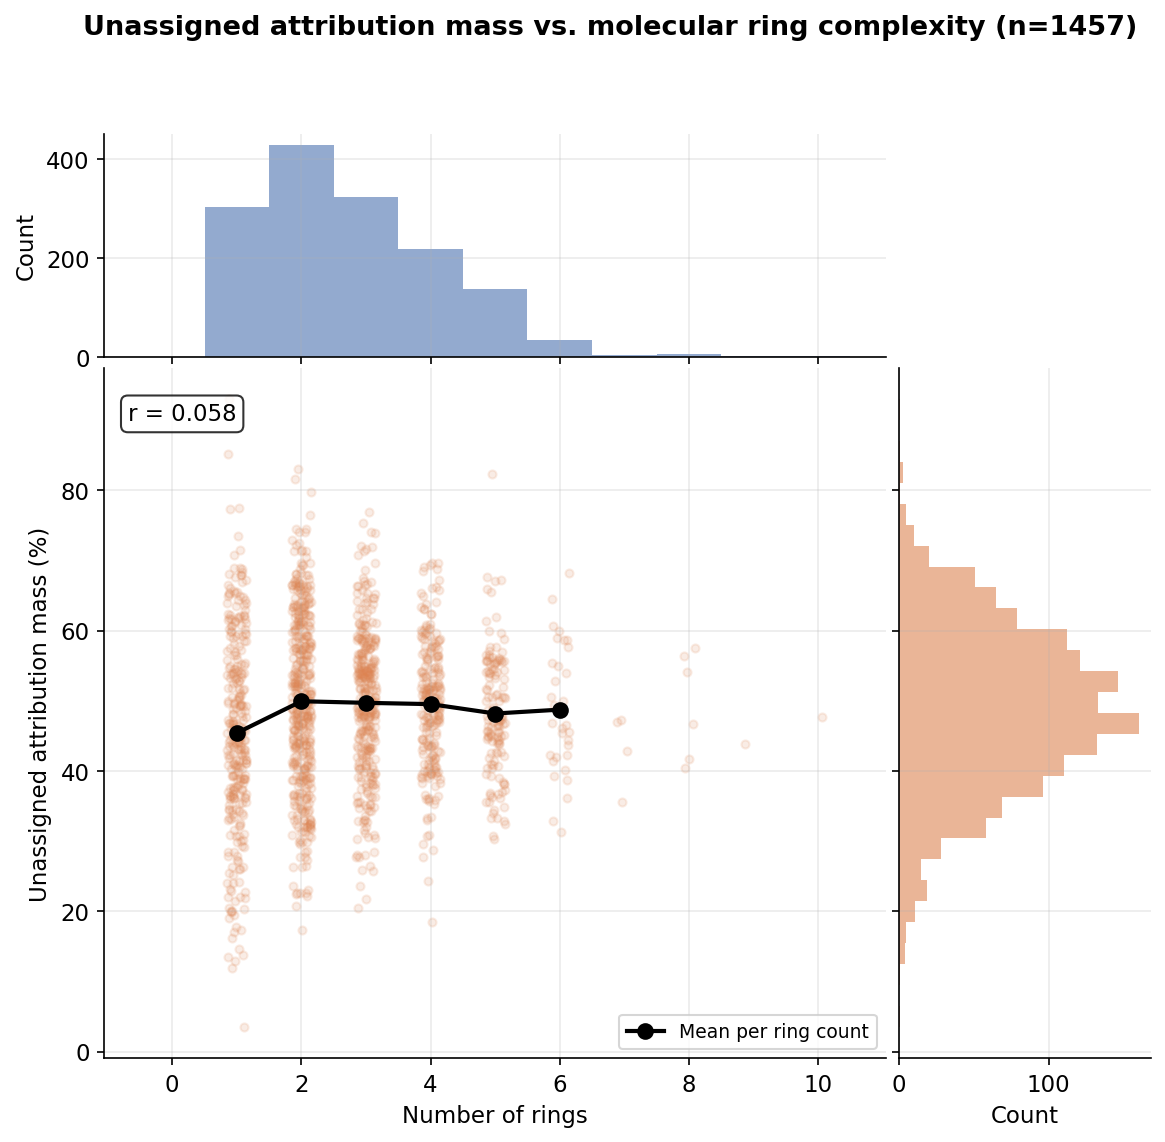

Saved fig5_unassigned_mass_vs_rings.png


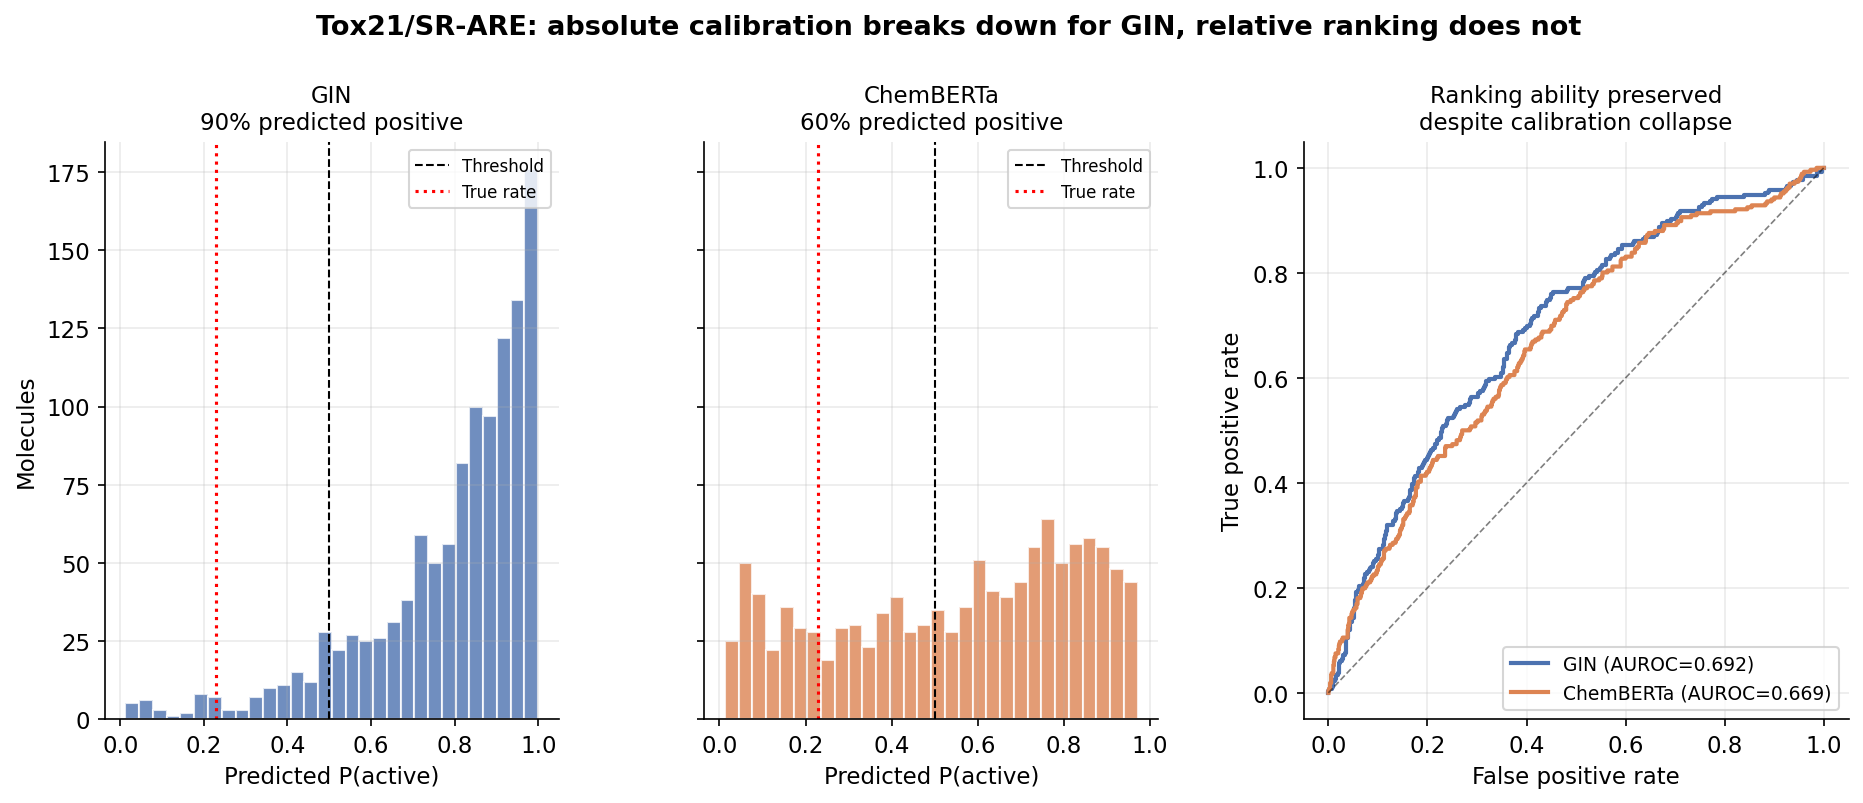

Saved fig6_tox21_calibration_and_roc.png

All v2 figures complete.


In [41]:
# =========================================================
# WRITE-UP FIGURES — v2, part 3.
# =========================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pickle
from sklearn.metrics import roc_curve, roc_auc_score

plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25,
})
GIN_COLOR, CB_COLOR = "#4C72B0", "#DD8452"

# =========================================================
# FIGURE 5 — Joint plot: unassigned attribution mass vs ring count,
# with marginal histogram. Uses the CONFIRMED Kaggle input path
# (not /kaggle/working/, which doesn't persist across sessions).
# =========================================================
CB_ATTR_PATH = "/kaggle/input/datasets/minoola33/chemberta-gin-attributions/chemberta_attributions.pkl"
with open(CB_ATTR_PATH, "rb") as f:
    chemberta_results_full = pickle.load(f)

unassigned_fracs, ring_counts = [], []
for v in chemberta_results_full.values():
    if not np.isnan(v["unassigned_fraction"]):
        unassigned_fracs.append(v["unassigned_fraction"] * 100)
        ring_counts.append(v["num_rings"])
unassigned_fracs = np.array(unassigned_fracs)
ring_counts = np.array(ring_counts)

fig = plt.figure(figsize=(9, 8))
gs = gridspec.GridSpec(4, 4, hspace=0.05, wspace=0.05)

ax_main = fig.add_subplot(gs[1:4, 0:3])
ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

# Jittered scatter (ring count is discrete)
jitter = np.random.RandomState(0).uniform(-0.15, 0.15, size=len(ring_counts))
ax_main.scatter(ring_counts + jitter, unassigned_fracs, alpha=0.15, s=15, color=CB_COLOR)

ring_bins = sorted(set(ring_counts))
ring_bins_use = [r for r in ring_bins if (ring_counts == r).sum() >= 15]
means_by_ring = [unassigned_fracs[ring_counts == r].mean() for r in ring_bins_use]
ax_main.plot(ring_bins_use, means_by_ring, 'o-', color='black', markersize=7, linewidth=2,
             label='Mean per ring count')
r_val = np.corrcoef(ring_counts, unassigned_fracs)[0, 1]
ax_main.set_xlabel("Number of rings")
ax_main.set_ylabel("Unassigned attribution mass (%)")
ax_main.legend(loc='lower right', fontsize=9)
ax_main.text(0.03, 0.95, f"r = {r_val:.3f}", transform=ax_main.transAxes, fontsize=11,
             va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax_top.hist(ring_counts, bins=np.arange(0, ring_counts.max() + 2) - 0.5, color=GIN_COLOR, alpha=0.6)
ax_top.tick_params(labelbottom=False)
ax_top.set_ylabel("Count")

ax_right.hist(unassigned_fracs, bins=30, orientation='horizontal', color=CB_COLOR, alpha=0.6)
ax_right.tick_params(labelleft=False)
ax_right.set_xlabel("Count")

fig.suptitle(f"Unassigned attribution mass vs. molecular ring complexity (n={len(unassigned_fracs)})",
             fontsize=13, fontweight='bold', y=0.98)
plt.savefig("/kaggle/working/figures/fig5_unassigned_mass_vs_rings.png", bbox_inches='tight')
plt.show()
print("Saved fig5_unassigned_mass_vs_rings.png")

# =========================================================
# FIGURE 6 — Tox21 calibration + ROC combined: shows the collapse
# in absolute calibration AND that relative ranking is preserved.
# =========================================================
gin_model_t.eval()
gin_probs_fig = []
gin_labels_fig = []
for d, (_, row) in zip(test_data_t, df_tox21_clean[df_tox21_clean['split'] == 'test'].iterrows()):
    d = d.to(device)
    batch = torch.zeros(d.x.size(0), dtype=torch.long, device=device)
    with torch.no_grad():
        logit = gin_model_t(d.x, d.edge_index, batch).item()
    gin_probs_fig.append(1 / (1 + np.exp(-logit)))
    gin_labels_fig.append(row['Y'])
gin_probs_fig = np.array(gin_probs_fig)
gin_labels_fig = np.array(gin_labels_fig)

chemberta_model_t.eval()
cb_probs_fig, cb_labels_fig = [], []
for _, row in df_tox21_clean[df_tox21_clean['split'] == 'test'].iterrows():
    enc = tokenizer_t(row['Drug_standardized'], return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        logits = chemberta_model_t(**enc).logits
    cb_probs_fig.append(torch.softmax(logits, dim=1)[0, 1].item())
    cb_labels_fig.append(row['Y'])
cb_probs_fig = np.array(cb_probs_fig)
cb_labels_fig = np.array(cb_labels_fig)

fig = plt.figure(figsize=(15, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.3)

ax0 = fig.add_subplot(gs[0])
ax0.hist(gin_probs_fig, bins=30, color=GIN_COLOR, alpha=0.8, edgecolor='white')
ax0.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax0.axvline(gin_labels_fig.mean(), color='red', linestyle=':', linewidth=1.5, label='True rate')
ax0.set_title(f"GIN\n{100*(gin_probs_fig>0.5).mean():.0f}% predicted positive", fontsize=11)
ax0.set_xlabel("Predicted P(active)")
ax0.set_ylabel("Molecules")
ax0.legend(fontsize=8)

ax1 = fig.add_subplot(gs[1], sharey=ax0)
ax1.hist(cb_probs_fig, bins=30, color=CB_COLOR, alpha=0.8, edgecolor='white')
ax1.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold')
ax1.axvline(cb_labels_fig.mean(), color='red', linestyle=':', linewidth=1.5, label='True rate')
ax1.set_title(f"ChemBERTa\n{100*(cb_probs_fig>0.5).mean():.0f}% predicted positive", fontsize=11)
ax1.set_xlabel("Predicted P(active)")
ax1.legend(fontsize=8)
ax1.tick_params(labelleft=False)

ax2 = fig.add_subplot(gs[2])
fpr_g, tpr_g, _ = roc_curve(gin_labels_fig, gin_probs_fig)
fpr_c, tpr_c, _ = roc_curve(cb_labels_fig, cb_probs_fig)
auc_g = roc_auc_score(gin_labels_fig, gin_probs_fig)
auc_c = roc_auc_score(cb_labels_fig, cb_probs_fig)
ax2.plot(fpr_g, tpr_g, color=GIN_COLOR, linewidth=2, label=f"GIN (AUROC={auc_g:.3f})")
ax2.plot(fpr_c, tpr_c, color=CB_COLOR, linewidth=2, label=f"ChemBERTa (AUROC={auc_c:.3f})")
ax2.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
ax2.set_xlabel("False positive rate")
ax2.set_ylabel("True positive rate")
ax2.set_title("Ranking ability preserved\ndespite calibration collapse", fontsize=11)
ax2.legend(fontsize=9, loc='lower right')

fig.suptitle("Tox21/SR-ARE: absolute calibration breaks down for GIN, relative ranking does not",
             fontsize=13, fontweight='bold', y=1.05)
plt.savefig("/kaggle/working/figures/fig6_tox21_calibration_and_roc.png", bbox_inches='tight')
plt.show()
print("Saved fig6_tox21_calibration_and_roc.png")

print("\nAll v2 figures complete.")

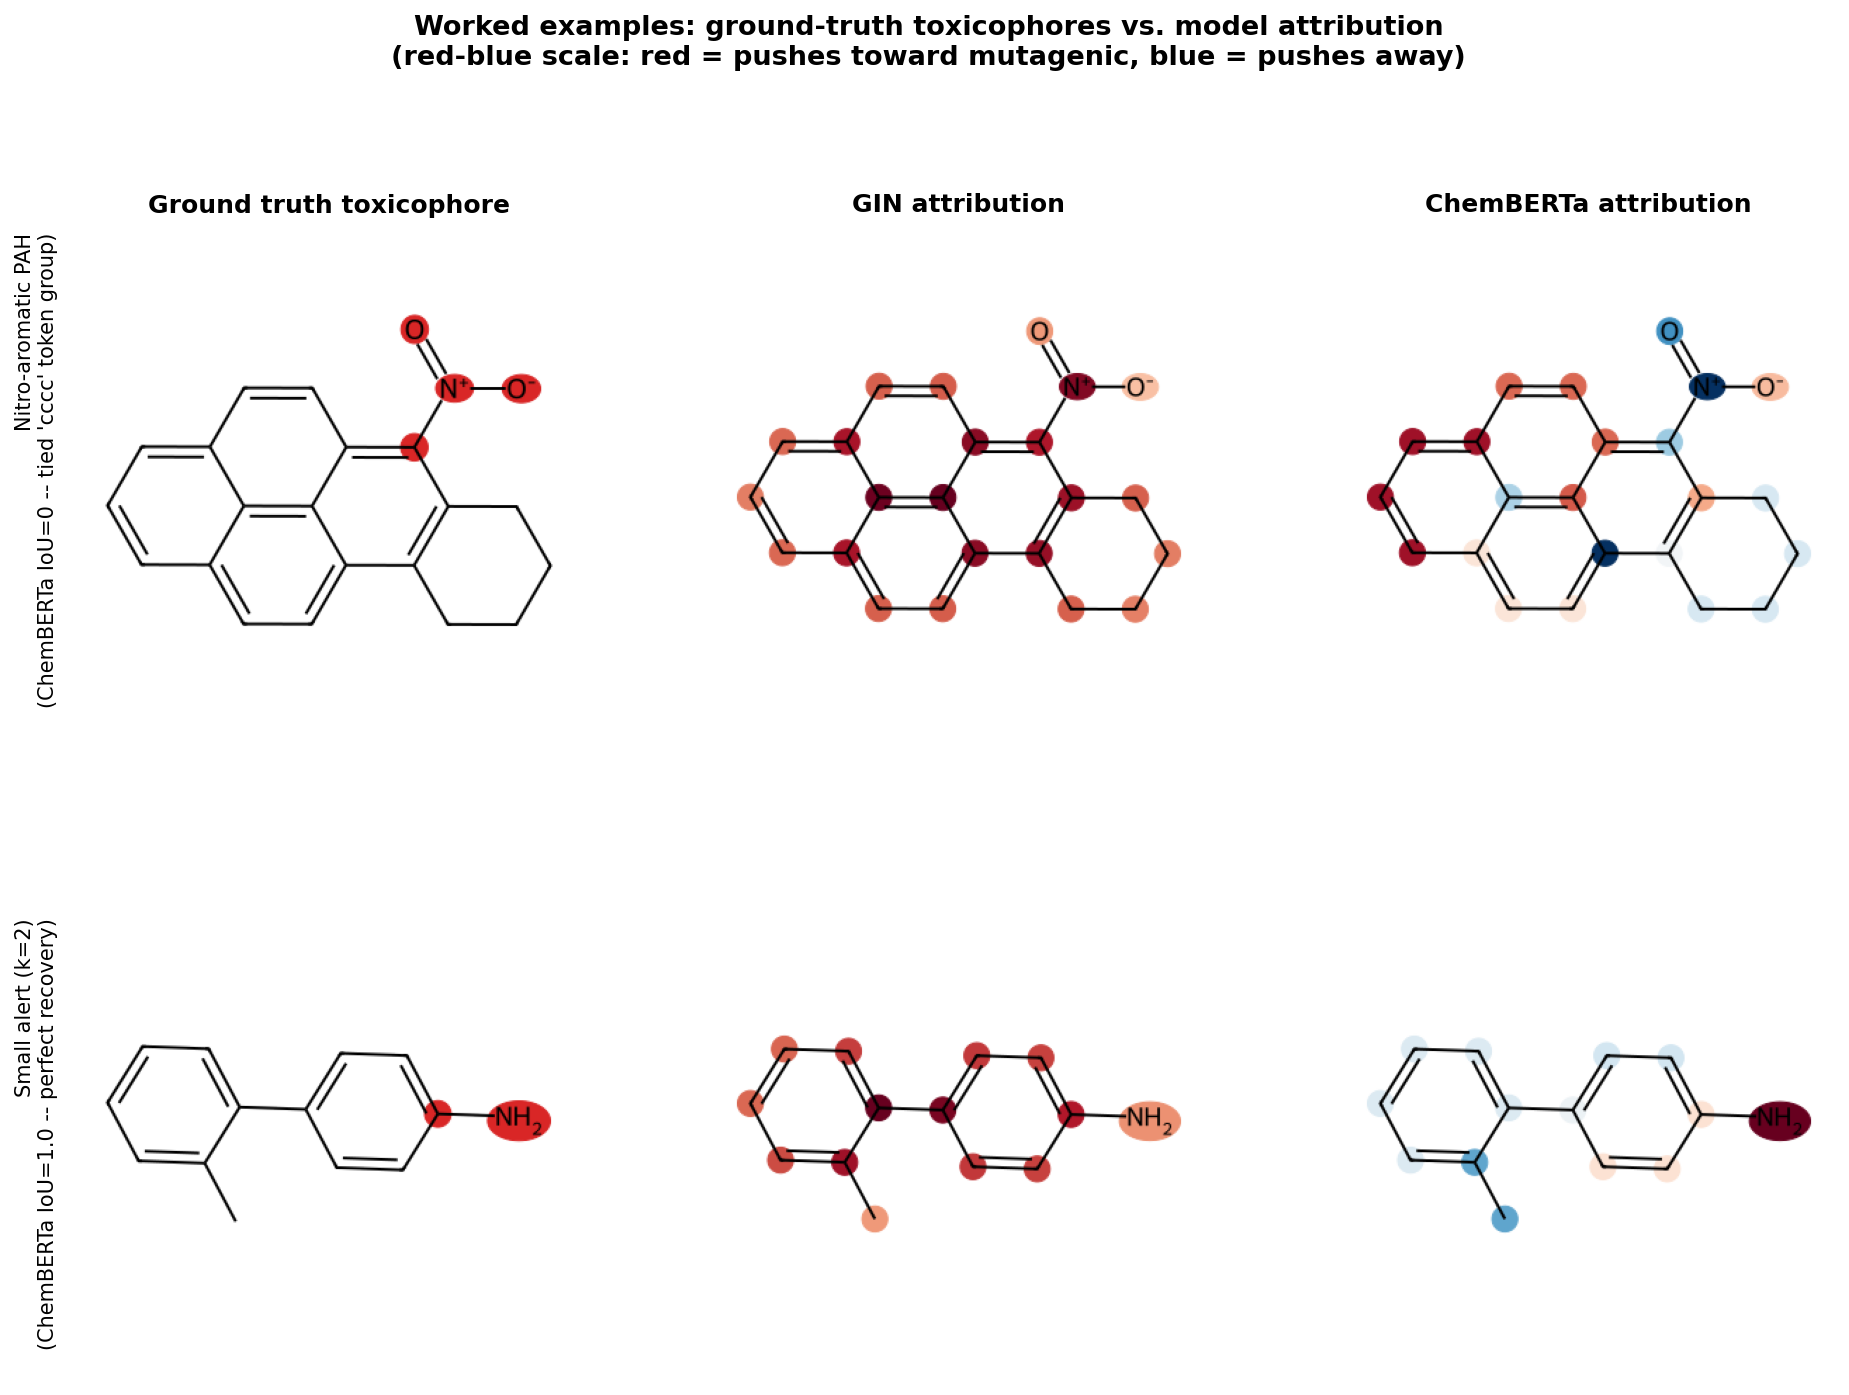

Saved fig7_molecule_interpretability_examples.png


In [44]:
# =========================================================
# FIGURE 7 — The actual interpretability visualization: molecules
# drawn with atoms colored by attribution score, ground truth vs
# GIN vs ChemBERTa, for concrete worked examples.
# This is the figure that makes "interpretable" visible, not just
# statistically argued.
# =========================================================

import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import gridspec
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from PIL import Image
import io

CB_ATTR_PATH = "/kaggle/input/datasets/minoola33/chemberta-gin-attributions/chemberta_attributions.pkl"
GIN_ATTR_PATH = "/kaggle/input/datasets/minoola33/chemberta-gin-attributions/gin_attributions.pkl"

with open(CB_ATTR_PATH, "rb") as f:
    chemberta_results_full = pickle.load(f)
with open(GIN_ATTR_PATH, "rb") as f:
    gin_attributions_full = pickle.load(f)

def attribution_to_colors(scores, cmap_name='RdBu_r'):
    """Signed attribution -> RGB per atom, symmetric around 0 so red/blue
    are directly comparable across panels."""
    vmax_abs = max(abs(scores.min()), abs(scores.max()), 1e-6)
    norm = mcolors.Normalize(vmin=-vmax_abs, vmax=vmax_abs)
    cmap = cm.get_cmap(cmap_name)
    return {i: cmap(norm(s))[:3] for i, s in enumerate(scores)}

def ground_truth_to_colors(mask):
    return {i: (0.85, 0.15, 0.15) for i, v in enumerate(mask) if v == 1}

def draw_molecule(smiles, atom_colors, size=(350, 350)):
    mol = Chem.MolFromSmiles(smiles)
    drawer = rdMolDraw2D.MolDraw2DCairo(*size)
    highlight_atoms = list(atom_colors.keys())
    rdMolDraw2D.PrepareAndDrawMolecule(
        drawer, mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors)
    drawer.FinishDrawing()
    return Image.open(io.BytesIO(drawer.GetDrawingText()))

# --- Example molecules: one "failure" case (tokenization cost), one "success" case ---
example_ids = ["Drug 1", "Drug 1494"]
example_titles = ["Nitro-aromatic PAH\n(ChemBERTa IoU=0 -- tied 'cccc' token group)",
                   "Small alert (k=2)\n(ChemBERTa IoU=1.0 -- perfect recovery)"]

fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(len(example_ids), 3, figure=fig, hspace=0.35, wspace=0.05)

for row, (did, title) in enumerate(zip(example_ids, example_titles)):
    if did not in ground_truth_masks or did not in gin_attributions_full or did not in chemberta_results_full:
        print(f"Skipping {did} -- not found in one of the required sources.")
        continue

    smiles = smiles_by_id[did]
    gt_mask = ground_truth_masks[did]
    gin_scores = gin_attributions_full[did]
    cb_scores = chemberta_results_full[did]["atom_scores"]

    gt_colors = ground_truth_to_colors(gt_mask)
    gin_colors = attribution_to_colors(gin_scores)
    cb_colors = attribution_to_colors(cb_scores)

    img_gt = draw_molecule(smiles, gt_colors)
    img_gin = draw_molecule(smiles, gin_colors)
    img_cb = draw_molecule(smiles, cb_colors)

    for col, img in enumerate([img_gt, img_gin, img_cb]):
        ax = fig.add_subplot(gs[row, col])
        ax.imshow(img)
        ax.axis('off')
        if row == 0:
            ax.set_title(["Ground truth toxicophore", "GIN attribution", "ChemBERTa attribution"][col],
                         fontsize=12, fontweight='bold')
        if col == 0:
            ax.text(-0.05, 0.5, title, transform=ax.transAxes, fontsize=10,
                    ha='right', va='center', rotation=90)

fig.suptitle("Worked examples: ground-truth toxicophores vs. model attribution\n"
             "(red-blue scale: red = pushes toward mutagenic, blue = pushes away)",
             fontsize=13, fontweight='bold', y=1.02)
plt.savefig("/kaggle/working/figures/fig7_molecule_interpretability_examples.png", bbox_inches='tight')
plt.show()
print("Saved fig7_molecule_interpretability_examples.png")